In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
import numpy as np

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.inspection import permutation_importance


In [2]:
df = pd.read_csv("cfos_densities_grey_tree_leaves_wide_format.csv")
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

In [3]:
meta = {'mouse_id', 'treatment', 'sex', 'time'}
region_cols = [c for c in df.columns if c not in meta]

In [4]:
y = (df['treatment'].astype(str).str.lower() == 'morphine').astype(int)

In [5]:
cov = pd.get_dummies(df[['sex', 'time']], drop_first=True)
X = pd.concat([df[region_cols], cov], axis=1)

In [6]:
X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

In [7]:
n_splits = 10

In [8]:
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

In [9]:
rf = RandomForestClassifier(
    n_estimators=300,      # fast & stable; bump if still very fast
    max_depth=None,        # or try 6/8/10 to reduce variance
    min_samples_leaf=2,    # regularization for tiny datasets
    max_features='sqrt',
    class_weight='balanced',  # helps if class imbalance exists
    n_jobs=-1,
    random_state=42
)

In [10]:
y_pred_cv = cross_val_predict(rf, X, y, cv=cv, method='predict')
print("Binary (morphine vs saline) — cross-validated performance:")

print(classification_report(y, y_pred_cv, target_names=['saline','morphine'], digits=3))

Binary (morphine vs saline) — cross-validated performance:
              precision    recall  f1-score   support

      saline      0.692     0.750     0.720        12
    morphine      0.786     0.733     0.759        15

    accuracy                          0.741        27
   macro avg      0.739     0.742     0.739        27
weighted avg      0.744     0.741     0.741        27



In [11]:
print("Confusion matrix (rows=true, cols=pred):")
print(confusion_matrix(y, y_pred_cv))

Confusion matrix (rows=true, cols=pred):
[[ 9  3]
 [ 4 11]]


In [12]:
rf.fit(X, y)

RandomForestClassifier(class_weight='balanced', min_samples_leaf=2,
                       n_estimators=300, n_jobs=-1, random_state=42)

In [13]:
feature_names = list(X.columns)


In [14]:
importances = pd.Series(rf.feature_importances_, index=feature_names)

In [15]:
importances

AAA        0.000000e+00
ACAd1      0.000000e+00
ACAd2/3    4.185944e-04
ACAd5      3.216350e-03
ACAd6a     2.319743e-02
               ...     
VPM        3.051595e-03
VTA        9.002635e-04
XII        4.741166e-18
sex_M      0.000000e+00
time_4h    0.000000e+00
Length: 302, dtype: float64

In [16]:
region_importance = importances[region_cols].sort_values(ascending=False)

In [17]:
region_importance.shape

(300,)

In [18]:
region_importance[region_importance > 0].shape

(244,)

In [19]:
region_name = "ACB"
rank = region_importance.index.get_loc(region_name) + 1  # +1 for 1-based rank
print(f"{region_name} is ranked #{rank} out of {len(region_importance)} regions.")

ACB is ranked #57 out of 300 regions.


In [20]:
region_name = "VTA"
rank = region_importance.index.get_loc(region_name) + 1  # +1 for 1-based rank
print(f"{region_name} is ranked #{rank} out of {len(region_importance)} regions.")

VTA is ranked #152 out of 300 regions.


In [21]:
top_k = 200
top_regions = region_importance.head(top_k)
print(f"\nTop {top_k} regions (RF Gini importance):")
print(top_regions)



Top 200 regions (RF Gini importance):
AUDp2/3    0.034931
ECT6a      0.029919
VISpor5    0.029893
ENTl5      0.029830
EPd        0.023513
             ...   
PL1        0.000488
APN        0.000487
ORBvl5     0.000482
VISp4      0.000471
ACAd2/3    0.000419
Length: 200, dtype: float64


## On the full df

In [22]:
df = pd.read_csv("cfos_densities_all_grey_structures_wide_format.csv")

In [23]:
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

In [24]:
meta = {'mouse_id', 'treatment', 'sex', 'time'}
region_cols = [c for c in df.columns if c not in meta]

In [25]:
y = (df['treatment'].astype(str).str.lower() == 'morphine').astype(int)

In [26]:
cov = pd.get_dummies(df[['sex', 'time']], drop_first=True)
X = pd.concat([df[region_cols], cov], axis=1)

In [27]:
X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

In [28]:
min_per_class = y.value_counts().min()
min_per_class

np.int64(12)

In [29]:
n_splits = 10

In [30]:
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

In [31]:
rf = RandomForestClassifier(
    n_estimators=300,      # fast & stable; bump if still very fast
    max_depth=None,        # or try 6/8/10 to reduce variance
    min_samples_leaf=2,    # regularization for tiny datasets
    max_features='sqrt',
    class_weight='balanced',  # helps if class imbalance exists
    n_jobs=-1,
    random_state=42
)

In [32]:
y_pred_cv = cross_val_predict(rf, X, y, cv=cv, method='predict')
print("Binary (morphine vs saline) — cross-validated performance:")

print(classification_report(y, y_pred_cv, target_names=['saline','morphine'], digits=3))

Binary (morphine vs saline) — cross-validated performance:
              precision    recall  f1-score   support

      saline      0.818     0.750     0.783        12
    morphine      0.812     0.867     0.839        15

    accuracy                          0.815        27
   macro avg      0.815     0.808     0.811        27
weighted avg      0.815     0.815     0.814        27



In [33]:
print("Confusion matrix (rows=true, cols=pred):")
print(confusion_matrix(y, y_pred_cv))

Confusion matrix (rows=true, cols=pred):
[[ 9  3]
 [ 2 13]]


In [34]:
rf.fit(X, y)

RandomForestClassifier(class_weight='balanced', min_samples_leaf=2,
                       n_estimators=300, n_jobs=-1, random_state=42)

In [35]:
feature_names = list(X.columns)

In [36]:
importances = pd.Series(rf.feature_importances_, index=feature_names)

In [37]:
region_importance = importances[region_cols].sort_values(ascending=False)

In [38]:
region_importance.shape

(722,)

In [39]:
region_importance.head(10)

ECT6a      0.030508
AUDp2/3    0.027547
LDT        0.023147
PERI5      0.020304
TEa5       0.019666
VISpor5    0.018818
PL6a       0.018240
VISli5     0.016579
ACAv       0.016342
ENTl5      0.015269
dtype: float64

In [40]:
region_importance[region_importance > 0].shape

(359,)

In [41]:
region_name = "ACB"
rank = region_importance.index.get_loc(region_name) + 1  # +1 for 1-based rank
print(f"{region_name} is ranked #{rank} out of {len(region_importance)} regions.")

ACB is ranked #177 out of 722 regions.


In [42]:
region_name = "VTA"
rank = region_importance.index.get_loc(region_name) + 1  # +1 for 1-based rank
print(f"{region_name} is ranked #{rank} out of {len(region_importance)} regions.")

VTA is ranked #138 out of 722 regions.


In [43]:
region_name = "PAG"
rank = region_importance.index.get_loc(region_name) + 1  # +1 for 1-based rank
print(f"{region_name} is ranked #{rank} out of {len(region_importance)} regions.")

PAG is ranked #28 out of 722 regions.


In [44]:
region_name = "DR"
rank = region_importance.index.get_loc(region_name) + 1  # +1 for 1-based rank
print(f"{region_name} is ranked #{rank} out of {len(region_importance)} regions.")

DR is ranked #16 out of 722 regions.


In [45]:
region_name = "CP"
rank = region_importance.index.get_loc(region_name) + 1  # +1 for 1-based rank
print(f"{region_name} is ranked #{rank} out of {len(region_importance)} regions.")

CP is ranked #223 out of 722 regions.


In [46]:
region_name = "BST"
rank = region_importance.index.get_loc(region_name) + 1  # +1 for 1-based rank
print(f"{region_name} is ranked #{rank} out of {len(region_importance)} regions.")

BST is ranked #299 out of 722 regions.


In [47]:
region_name = "CEA"
rank = region_importance.index.get_loc(region_name) + 1  # +1 for 1-based rank
print(f"{region_name} is ranked #{rank} out of {len(region_importance)} regions.")

CEA is ranked #253 out of 722 regions.


In [48]:
contributing_regions = region_importance[region_importance > 0].index

In [49]:
contributing_regions = list(contributing_regions)

In [50]:
contributing_regions.index('DR')

15

In [51]:
# atlas related
from bg_atlasapi.bg_atlas import BrainGlobeAtlas
import json

atlas = BrainGlobeAtlas("allen_mouse_10um")
tree = atlas.structures.tree
root_node_id = tree.root
get_acronym = lambda x: x.split(">")[-1]

# "csv_files" archive needs to be downloaded and unpacked (see README.md file for instructions)
region_volumes = json.load(open("csv_files/region_volumes_10um.json", "r"))

def structure_from_acronym(acronym):
    return ">".join(atlas.get_structure_ancestors(acronym) + [acronym])

def exclude_parents(acronyms):
    """
    Goes through the list of acronyms, and removes structures that are parents of other structures in this list.
    For example, if list contains both ACB and STR (STR being parent of ACB), this function will exclude STR
    """
    acronyms_filtered = acronyms[:]
    for acronym in acronyms:
        parents = atlas.get_structure_ancestors(acronym)
        for parent in parents:
            if parent in acronyms_filtered:
                acronyms_filtered.remove(parent)
    return acronyms_filtered

def get_major_parent(acronym):
    parents = atlas.get_structure_ancestors(acronym)
    for structure in large_structures:
        if structure in parents:
            return structure
    return "Other"

In [52]:
contributing_regions_no_parents = exclude_parents(contributing_regions)

In [53]:
len(contributing_regions_no_parents)

276

In [54]:
importance_contributing_regions_no_parents = region_importance[contributing_regions_no_parents]

In [55]:
importance_contributing_regions_no_parents.sort_values(ascending=False, inplace=True)

In [56]:
lmm_df_full = pd.read_csv('cfos_densities_real_all_grey_structures.csv')

In [57]:
df_long_contributing_regions = lmm_df_full[lmm_df_full['region'].isin(contributing_regions)]

In [58]:
df_long_contributing_regions.to_csv('cfos_densities_contributing_regions_random_forest.csv')

In [59]:
region_importance.to_csv('random_forest_region_importance.csv')

# Linear mixed model

In [60]:
import os
import json
from collections import Counter, defaultdict
from glob import glob

# import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
# import plotly.express as px
# import plotly.graph_objects as go
# import seaborn as sns
from IPython.display import display, HTML
from bg_atlasapi.bg_atlas import BrainGlobeAtlas
# from brainrender import Scene
# from brainrender._colors import map_color
from datetime import datetime
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

from scipy.stats import levene
import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

In [61]:
def cohend(d1, d2):
	# calculate the size of samples
	n1, n2 = len(d1), len(d2)
	# calculate the variance of the samples
	s1, s2 = np.var(d1, ddof=1), np.var(d2, ddof=1)
	# calculate the pooled standard deviation
	s = np.sqrt(((n1 - 1) * s1 + (n2 - 1) * s2) / (n1 + n2 - 2))
	# calculate the means of the samples
	u1, u2 = np.mean(d1), np.mean(d2)
	# calculate the effect size
	return (u1 - u2) / s

### Main effect (Morphine vs Saline) Male 1h

In [62]:
import warnings

with warnings.catch_warnings():
    warnings.simplefilter("ignore")

    betas = []
    beta_lower_cis = []
    beta_upper_cis = []
    effects = []
    lower_cis = []
    upper_cis = []
    pvals = []
    empirical_ds = []
    
    for abbr in contributing_regions_no_parents:
        sub = lmm_df_full[lmm_df_full["region"] == abbr].copy()
        
        sub["treatment"] = pd.Categorical(sub["treatment"], categories=["saline", "morphine"], ordered=True)
        sub["time"]      = pd.Categorical(sub["time"], categories=["1h", "4h"], ordered=True)
        sub["sex"]       = pd.Categorical(sub["sex"], categories=["M", "F"], ordered=True)
        
        
        # Fit the mixed model: density ~ treatment * time * sex + (1 | mouse_id)
        md = smf.mixedlm("density ~ C(treatment) * C(time) * C(sex)", 
                         data=sub, 
                         groups=sub["mouse_id"])
        m = md.fit(reml=True, method="lbfgs")
    
        # Check: print(m.params.index.tolist())
        b_tr_name   = "C(treatment)[T.morphine]"
        
        # Point estimate = sum of betas
        beta = m.params[b_tr_name]
        se_beta = m.bse[b_tr_name]
        beta_lcl = beta - 1.96*se_beta
        beta_ucl = beta + 1.96*se_beta
       
        # Standardize to marginal Cohen's d
        sigma_eps = float(np.sqrt(m.scale))  # residual SD
        var_u0 = float(m.cov_re.iloc[0, 0])  # random-intercept variance
        sd_marg = float(np.sqrt(m.scale + var_u0))  # marginal SD (Random intercept model)
    
        d_marg = beta / sd_marg
        se_d_marg = se_beta / sd_marg
        
        ci_d = (d_marg - 1.96*se_d_marg, d_marg + 1.96*se_d_marg)
        pval  = m.pvalues[b_tr_name]
    
        mor = sub[(sub['treatment'] == "morphine") & (sub['time'] == "1h") & (sub['sex'] == "M")]
        sal = sub[(sub['treatment'] == "saline") & (sub['time'] == "1h") & (sub['sex'] == "M")]
        d_empirical = cohend(mor['density'].to_numpy(), sal['density'].to_numpy())
    
        betas.append(beta)
        beta_lower_cis.append(beta_lcl)
        beta_upper_cis.append(beta_ucl)
        effects.append(d_marg)
        empirical_ds.append(d_empirical)
        lower_cis.append(ci_d[0])
        upper_cis.append(ci_d[1])
        pvals.append(pval)
    
    results_df = pd.DataFrame()
    results_df['structure'] = contributing_regions_no_parents
    results_df['beta'] = betas
    results_df['beta_lower_ci'] = beta_lower_cis
    results_df['beta_upper_ci'] = beta_upper_cis
    results_df['effect'] = effects
    results_df['empirical_d'] = empirical_ds
    results_df['lower_ci'] = lower_cis
    results_df['upper_ci'] = upper_cis
    results_df['abs_effect'] = np.abs(results_df['effect'].to_list())
    results_df['p'] = pvals
    reject, pvals_corrected, alphacSidak, alphacBonf = multipletests(
        pvals, alpha=0.05, method="fdr_bh"  # Benjamini-Hochberg FDR
    )
    results_df['q'] = pvals_corrected
    results_df.sort_values('abs_effect', ascending=False, inplace=True)

In [63]:
from IPython.display import display, HTML
display(HTML(results_df.to_html()))

,structure,beta,beta_lower_ci,beta_upper_ci,effect,empirical_d,lower_ci,upper_ci,abs_effect,p,q
9,EPd,750.016577,531.911250,968.121904,3.894239,2.968896,2.761792,5.026686,3.894239,1.583737e-11,4.371114e-09
54,PP,483.012779,212.291092,753.734465,2.539573,1.578072,1.116179,3.962967,2.539573,4.705785e-04,7.639980e-03
20,VISp5,1163.959963,687.776689,1640.143237,2.458707,1.499942,1.452835,3.464580,2.458707,1.660087e-06,2.290920e-04
52,AUDpo6b,525.380807,305.089818,745.671796,2.419535,2.755313,1.405029,3.434040,2.419535,2.946957e-06,2.711201e-04
8,ENTl5,1145.550894,473.286485,1817.815303,2.417641,1.857271,0.998853,3.836429,2.417641,8.381581e-04,1.054743e-02
74,VISpl6a,877.503713,424.919744,1330.087683,2.303857,4.748936,1.115613,3.492102,2.303857,1.445823e-04,3.069594e-03
43,ENTm6,1034.174443,413.725710,1654.623177,2.223759,1.961769,0.889624,3.557894,2.223759,1.087086e-03,1.153984e-02
55,ACAv6b,504.871473,277.814331,731.928614,2.198480,1.479627,1.209752,3.187208,2.198480,1.311691e-05,5.171810e-04
59,ProS,350.737165,195.054982,506.419349,2.182995,4.798459,1.214026,3.151964,2.182995,1.006866e-05,4.700229e-04
7,VISli5,1352.745822,584.639082,2120.852561,2.158074,1.911567,0.932691,3.383456,2.158074,5.567771e-04,8.408319e-03


In [64]:
results_df[results_df["q"] < 0.05]

,structure,beta,beta_lower_ci,beta_upper_ci,effect,empirical_d,lower_ci,upper_ci,abs_effect,p,q
9,EPd,750.016577,531.911250,968.121904,3.894239,2.968896,2.761792,5.026686,3.894239,1.583737e-11,4.371114e-09
54,PP,483.012779,212.291092,753.734465,2.539573,1.578072,1.116179,3.962967,2.539573,4.705785e-04,7.639980e-03
20,VISp5,1163.959963,687.776689,1640.143237,2.458707,1.499942,1.452835,3.464580,2.458707,1.660087e-06,2.290920e-04
52,AUDpo6b,525.380807,305.089818,745.671796,2.419535,2.755313,1.405029,3.434040,2.419535,2.946957e-06,2.711201e-04
8,ENTl5,1145.550894,473.286485,1817.815303,2.417641,1.857271,0.998853,3.836429,2.417641,8.381581e-04,1.054743e-02
74,VISpl6a,877.503713,424.919744,1330.087683,2.303857,4.748936,1.115613,3.492102,2.303857,1.445823e-04,3.069594e-03
43,ENTm6,1034.174443,413.725710,1654.623177,2.223759,1.961769,0.889624,3.557894,2.223759,1.087086e-03,1.153984e-02
55,ACAv6b,504.871473,277.814331,731.928614,2.198480,1.479627,1.209752,3.187208,2.198480,1.311691e-05,5.171810e-04
59,ProS,350.737165,195.054982,506.419349,2.182995,4.798459,1.214026,3.151964,2.182995,1.006866e-05,4.700229e-04
7,VISli5,1352.745822,584.639082,2120.852561,2.158074,1.911567,0.932691,3.383456,2.158074,5.567771e-04,8.408319e-03


In [65]:
results_df[results_df["q"] < 0.05].shape

(45, 11)

In [66]:
d_thresh = 0.8
results_df_large = results_df[results_df['abs_effect'] >= d_thresh]
positive_effects = results_df_large[results_df_large['effect'] > 0]
positive_effects = positive_effects[positive_effects["lower_ci"] > 0]
positive_effects.shape

(79, 11)

In [67]:
negative_effects = results_df[results_df['effect'] < 0]
negative_effects = negative_effects[negative_effects["upper_ci"] < 0]
negative_effects.shape

(3, 11)

In [68]:
df = pd.concat([positive_effects.copy(), negative_effects.copy()])
df = df.sort_values("effect", ascending=False).reset_index(drop=True)

In [69]:
df = df[df["structure"].isin(results_df[results_df["q"] < 0.05]['structure'].to_list())]

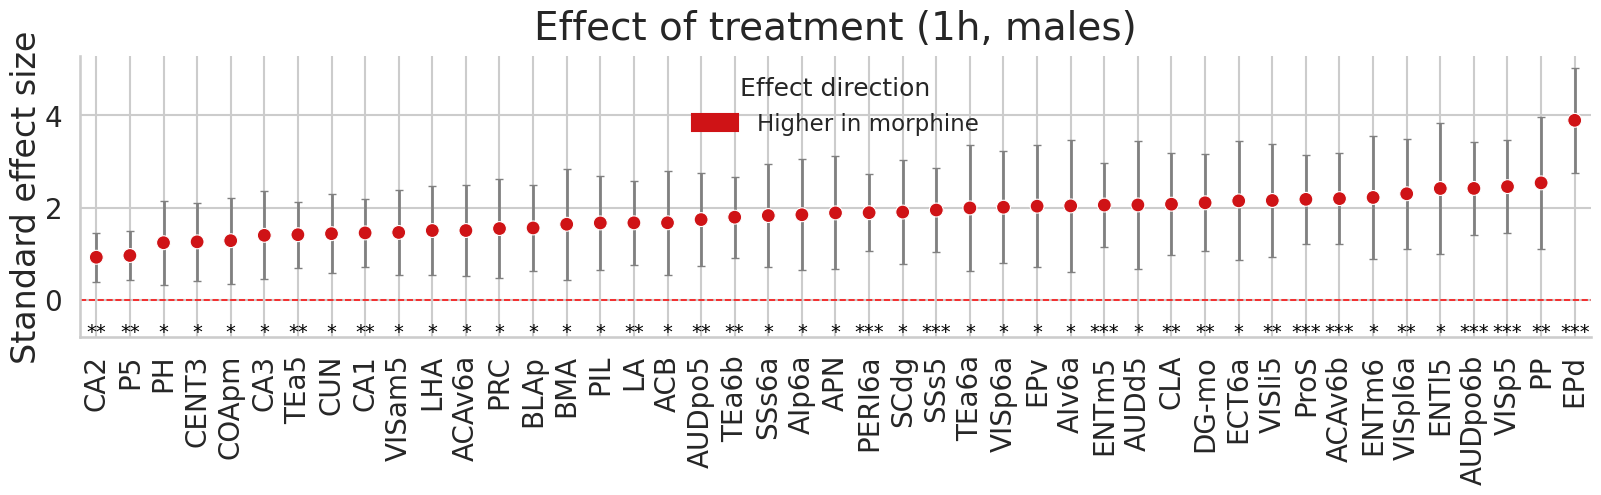

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# --- Prep
df = df.sort_values("effect").reset_index(drop=True)
df["sign"] = np.where(df["effect"] >= 0, "positive", "negative")
order = list(df["structure"])
xpos = np.arange(len(df))

# --- Theme
sns.set_theme(style="whitegrid", context="talk")  # "talk" = larger fonts
plt.rcParams.update({
    "axes.labelsize": 24,
    "axes.titlesize": 28,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "font.weight": "regular"
})

# --- Figure
fig_w = 0.35 * len(df)
fig_h = 5
fig, ax = plt.subplots(figsize=(fig_w, fig_h))

# Scatter points
sns.scatterplot(
    x=xpos,
    y=df["effect"],
    hue=df["sign"],
    palette={"positive": "#cf1316", "negative": "#0f3e8a"},
    s=100,
    ax=ax,
    legend=False,
    zorder=3
)

# Vertical CI bars
for x, row in zip(xpos, df.itertuples()):
    ax.errorbar(
        x=x,
        y=row.effect,
        yerr=[[row.effect - row.lower_ci],
              [row.upper_ci - row.effect]],
        fmt="none",
        ecolor="gray",
        elinewidth=2,
        capsize=3,
        alpha=1,
        zorder=2
    )

# Reference line
ax.axhline(0, color="red", linestyle="--", lw=1.2, alpha=0.9)

# Labels
# ax.set_xlabel("Brain structure", labelpad=1)
ax.set_xlabel("")
ax.set_ylabel("Standard effect size", labelpad=1)
ax.set_title("Effect of treatment (1h, males)", pad=12)

# Ticks
ax.set_xticks(xpos)
ax.set_xticklabels(order, rotation=90, ha="center")

import matplotlib.patches as mpatches

legend_patches = [
    mpatches.Patch(color="#cf1316", label="Higher in morphine"),
    # mpatches.Patch(color="#ff7f0e", label="Negative effect"),
]

ax.legend(
    handles=legend_patches,
    title="Effect direction",
    loc="upper center",
    bbox_to_anchor=(0.5, 1),
    # ncol=2,
    frameon=False
)

# --- Layout tweaks
ax.set_xlim(-0.5, len(df) - 0.5)
sns.despine(left=False, bottom=False)
plt.tight_layout(pad=0.5)          # tighten figure padding
plt.subplots_adjust(left=0.02, right=0.98, bottom=0.32)  # reduce side margins

pval_col = "q"
def p_to_stars(p):
    if pd.isna(p): return ""
    if p < 1e-3:  return "***"
    if p < 1e-2:  return "**"
    if p < 0.05:  return "*"
    return ""

stars = df[pval_col].map(p_to_stars)

# Choose where that stars row lives (in data units)
ymin, ymax = ax.get_ylim()
rng = ymax - ymin
y_star = ymin - 0.08 * rng   # 8% below the current min (pick any value you like)

# Make sure the stars aren’t clipped
if y_star < ymin:
    ax.set_ylim(y_star - 0.02 * rng, ymax)  # tiny padding below

# Draw the star labels under each structure
for x, s in zip(xpos, stars):
    if s:
        ax.text(x, y_star, s, ha="center", va="center",
                fontsize=14, color="black", clip_on=False)

SCREENSHOTS_FOLDER = "/h20/CBI/Iana/papers/CEBRA_cFOs/plots/forest"
plt.savefig(
    os.path.join(SCREENSHOTS_FOLDER, "simple_effect_treatment_males_1h_d_marg.png"),
    dpi=300, bbox_inches="tight", transparent=True
)
plt.show()

In [71]:
df = pd.concat([positive_effects.copy(), negative_effects.copy()])
df = df.sort_values("effect", ascending=False).reset_index(drop=True)
structures_1h_male = df["structure"].to_list()
len(structures_1h_male)

82

### Main effect (Morphine vs Saline) Male 4h

In [72]:
import numpy as np
from scipy import stats

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    betas = []
    beta_lower_cis = []
    beta_upper_cis = []
    effects = []
    lower_cis = []
    upper_cis = []
    pvals = []
    
    for abbr in contributing_regions_no_parents:
        sub = lmm_df_full[lmm_df_full["region"] == abbr].copy()
        
        sub["treatment"] = pd.Categorical(sub["treatment"], categories=["saline", "morphine"], ordered=True)
        sub["time"]      = pd.Categorical(sub["time"], categories=["1h", "4h"], ordered=True)
        sub["sex"]       = pd.Categorical(sub["sex"], categories=["M", "F"], ordered=True)
        
        
        # 3) Fit the mixed model: density ~ treatment * time * sex + (1 | mouse_id)
        md = smf.mixedlm("density ~ C(treatment) * C(time) * C(sex)", 
                         data=sub, 
                         groups=sub["mouse_id"])
        m = md.fit(reml=True, method="lbfgs")
    
        b_tr   = m.params["C(treatment)[T.morphine]"]
        b_tr_t = m.params["C(treatment)[T.morphine]:C(time)[T.4h]"]
        
        # Point estimate: sum of the two betas
        est = b_tr + b_tr_t
        
        # --- Uncertainty for a sum of betas ---
        # Var(aX + bY) = a^2 Var(X) + b^2 Var(Y) + 2ab Cov(X, Y)
        cov = m.cov_params()
        v_tr   = cov.loc["C(treatment)[T.morphine]", "C(treatment)[T.morphine]"]
        v_tr_t = cov.loc["C(treatment)[T.morphine]:C(time)[T.4h]",
                         "C(treatment)[T.morphine]:C(time)[T.4h]"]
        c_tr_trt = cov.loc["C(treatment)[T.morphine]",
                           "C(treatment)[T.morphine]:C(time)[T.4h]"]
        
        se = float(np.sqrt(v_tr + v_tr_t + 2*c_tr_trt))
        
        ci = (est - 1.96*se, est + 1.96*se)
        
        var_u0 = float(m.cov_re.iloc[0, 0])      # random-intercept variance
        sd_marg = float(np.sqrt(m.scale + var_u0))
        d_marg = est / sd_marg
        ci_d_marg = (ci[0]/sd_marg, ci[1]/sd_marg)
        
        effects.append(d_marg)
        lower_cis.append(ci_d_marg[0])
        upper_cis.append(ci_d_marg[1])
    
        fe_names = m.fe_params.index
        w = pd.Series(0.0, index=fe_names) 
        w["C(treatment)[T.morphine]"] = 1.0
        w["C(treatment)[T.morphine]:C(time)[T.4h]"] = 1.0
        tt    = m.t_test(w.values[None, :])
        pval = float(tt.pvalue)
    
        betas.append(est)
        beta_lower_cis.append(ci[0])
        beta_upper_cis.append(ci[1])
        pvals.append(pval)
    
    results_df = pd.DataFrame()
    results_df['structure'] = contributing_regions_no_parents
    results_df['beta'] = betas
    results_df['beta_lower_ci'] = beta_lower_cis
    results_df['beta_upper_ci'] = beta_upper_cis
    results_df['effect'] = effects
    results_df['lower_ci'] = lower_cis
    results_df['upper_ci'] = upper_cis
    results_df['abs_effect'] = np.abs(results_df['effect'].to_list())
    results_df['p'] = pvals
    reject, pvals_corrected, alphacSidak, alphacBonf = multipletests(
        pvals, alpha=0.05, method="fdr_bh"  # Benjamini-Hochberg FDR
    )
    results_df['q'] = pvals_corrected
    results_df.sort_values('abs_effect', ascending=False, inplace=True)

In [73]:
d_thresh = 0.8
results_df_large = results_df[results_df['abs_effect'] >= d_thresh]
positive_effects = results_df_large[results_df_large['effect'] > 0]
positive_effects = positive_effects[positive_effects["lower_ci"] > 0]
positive_effects.shape

(37, 10)

In [74]:
negative_effects = results_df[results_df['effect'] < 0]
negative_effects = negative_effects[negative_effects["upper_ci"] < 0]
negative_effects.shape

(0, 10)

In [75]:
df = pd.concat([positive_effects.copy(), negative_effects.copy()])
df = df.sort_values("effect", ascending=False).reset_index(drop=True)

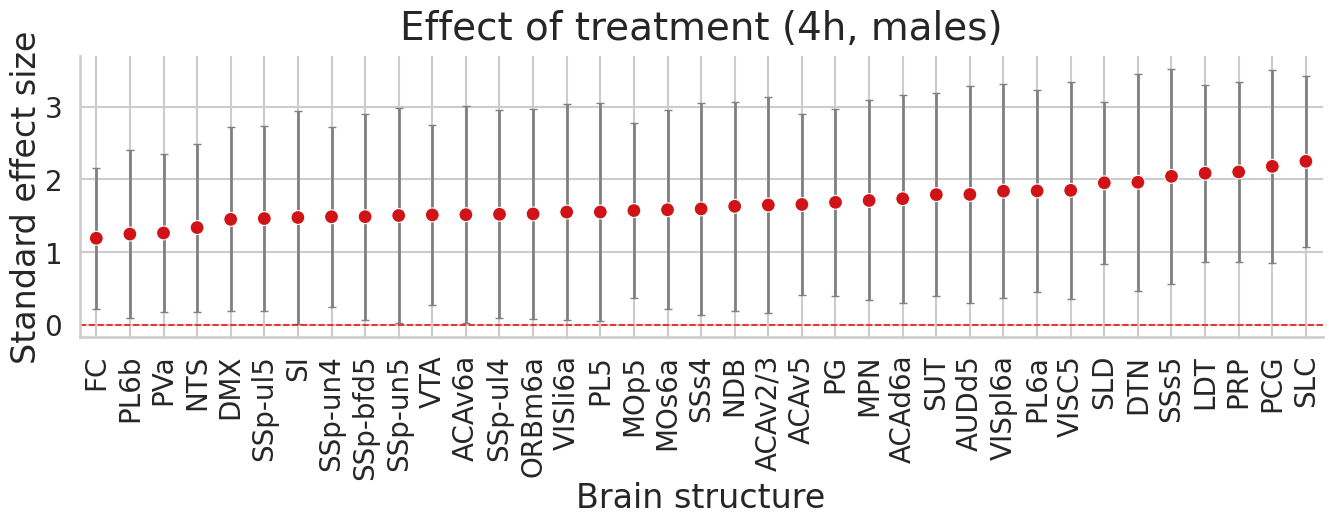

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# --- Prep
df = df.sort_values("effect").reset_index(drop=True)
df["sign"] = np.where(df["effect"] >= 0, "positive", "negative")

order = list(df["structure"])
xpos = np.arange(len(df))

# --- Theme
sns.set_theme(style="whitegrid", context="talk")  # "talk" = larger fonts
plt.rcParams.update({
    "axes.labelsize": 24,
    "axes.titlesize": 28,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "font.weight": "regular"
})

# --- Figure
fig_w = max(12, 0.35 * len(df))
fig_h = 5
fig, ax = plt.subplots(figsize=(fig_w, fig_h))

# Scatter points
sns.scatterplot(
    x=xpos,
    y=df["effect"],
    hue=df["sign"],
    palette={"positive": "#cf1316", "negative": "#0f3e8a"},
    s=100,
    ax=ax,
    legend=False,
    zorder=3
)

# Vertical CI bars
for x, row in zip(xpos, df.itertuples()):
    ax.errorbar(
        x=x,
        y=row.effect,
        yerr=[[row.effect - row.lower_ci],
              [row.upper_ci - row.effect]],
        fmt="none",
        ecolor="gray",
        elinewidth=2,
        capsize=3,
        alpha=1,
        zorder=2
    )

# Reference line
ax.axhline(0, color="red", linestyle="--", lw=1.2, alpha=0.9)

# Labels
ax.set_xlabel("Brain structure", labelpad=1)
ax.set_ylabel("Standard effect size", labelpad=1)
ax.set_title("Effect of treatment (4h, males)", pad=12)

# Ticks
ax.set_xticks(xpos)
ax.set_xticklabels(order, rotation=90, ha="center")

# --- Layout tweaks
ax.set_xlim(-0.5, len(df) - 0.5)
sns.despine(left=False, bottom=False)
plt.tight_layout(pad=0.5)          # tighten figure padding
plt.subplots_adjust(left=0.02, right=0.98, bottom=0.32)  # reduce side margins

plt.savefig(
    os.path.join(SCREENSHOTS_FOLDER, "simple_effect_treatment_males_4h_d_marg.png"),
    dpi=300, bbox_inches="tight", transparent=True
)
plt.show()

In [77]:
structures_4h_male = df["structure"].to_list()
len(structures_4h_male)

37

## Main effect (Morphine vs Saline) 1h females

In [78]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    betas = []
    beta_lower_cis = []
    beta_upper_cis = []
    effects = []
    lower_cis = []
    upper_cis = []
    pvals = []
    
    for abbr in contributing_regions_no_parents:
        sub = lmm_df_full[lmm_df_full["region"] == abbr].copy()
        
        sub["treatment"] = pd.Categorical(sub["treatment"], categories=["saline", "morphine"], ordered=True)
        sub["time"]      = pd.Categorical(sub["time"], categories=["1h", "4h"], ordered=True)
        sub["sex"]       = pd.Categorical(sub["sex"], categories=["M", "F"], ordered=True)
        
        
        # 3) Fit the mixed model: density ~ treatment * time * sex + (1 | mouse_id)
        md = smf.mixedlm("density ~ C(treatment) * C(time) * C(sex)", 
                         data=sub, 
                         groups=sub["mouse_id"])
        m = md.fit(reml=True, method="lbfgs")
    
        # Check: print(m.params.index.tolist())
        b_tr_name   = "C(treatment)[T.morphine]"
        b_tr_sexF   = "C(treatment)[T.morphine]:C(sex)[T.F]"
        
        # Point estimate = sum of betas
        b_tr = m.params[b_tr_name]
        b_tf = m.params[b_tr_sexF]
        est = float(b_tr + b_tf)
        
        # SE via variance-of-a-sum: Var(X+Y)=Var(X)+Var(Y)+2*Cov(X,Y)
        cov = m.cov_params()
        v_tr = cov.loc[b_tr_name, b_tr_name]
        v_tf = cov.loc[b_tr_sexF, b_tr_sexF]
        c_tr_tf = cov.loc[b_tr_name, b_tr_sexF]
        se = float(np.sqrt(v_tr + v_tf + 2*c_tr_tf))
    
        ci = (est - 1.96*se, est + 1.96*se)
        
        var_u0 = float(m.cov_re.iloc[0, 0])      # random-intercept variance
        sd_marg = float(np.sqrt(m.scale + var_u0))
        d_marg = est / sd_marg
        ci_d_marg = (ci[0]/sd_marg, ci[1]/sd_marg)
        
        effects.append(d_marg)
        lower_cis.append(ci_d_marg[0])
        upper_cis.append(ci_d_marg[1])
    
        fe_names = m.fe_params.index
        w = pd.Series(0.0, index=fe_names) 
        w["C(treatment)[T.morphine]"] = 1.0
        w["C(treatment)[T.morphine]:C(sex)[T.F]"] = 1.0
        tt = m.t_test(w.values[None, :])
        pval = float(tt.pvalue)
    
        betas.append(est)
        beta_lower_cis.append(ci[0])
        beta_upper_cis.append(ci[1])
        pvals.append(pval)
    
    results_df = pd.DataFrame()
    results_df['structure'] = contributing_regions_no_parents
    results_df['beta'] = betas
    results_df['beta_lower_ci'] = beta_lower_cis
    results_df['beta_upper_ci'] = beta_upper_cis
    results_df['effect'] = effects
    results_df['lower_ci'] = lower_cis
    results_df['upper_ci'] = upper_cis
    results_df['abs_effect'] = np.abs(results_df['effect'].to_list())
    results_df['p'] = pvals
    reject, pvals_corrected, alphacSidak, alphacBonf = multipletests(
        pvals, alpha=0.05, method="fdr_bh"  # Benjamini-Hochberg FDR
    )
    results_df['q'] = pvals_corrected
    results_df.sort_values('abs_effect', ascending=False, inplace=True)

In [79]:
results_df[results_df["q"] < 0.05]

,structure,beta,beta_lower_ci,beta_upper_ci,effect,lower_ci,upper_ci,abs_effect,p,q
133,PVT,-1556.861439,-2120.320745,-993.402133,-3.145655,-4.284130,-2.007179,3.145655,6.109673e-08,0.000017
252,AUDp6b,-407.269305,-610.660435,-203.878174,-2.787642,-4.179796,-1.395488,2.787642,8.684025e-05,0.011682
88,PRC,-1458.648202,-2204.674108,-712.622297,-2.491613,-3.765949,-1.217277,2.491613,1.269817e-04,0.011682
188,LSv,-1520.276576,-2319.365016,-721.188135,-2.460544,-3.753857,-1.167232,2.460544,1.922972e-04,0.013269
272,SPFm,-1631.608490,-2641.445371,-621.771609,-2.287587,-3.703422,-0.871751,2.287587,1.541256e-03,0.043377
227,BST,-527.584305,-822.422828,-232.745783,-2.235861,-3.485364,-0.986359,2.235861,4.528049e-04,0.017853
69,VLPO,-812.622912,-1310.676162,-314.569663,-2.228832,-3.594873,-0.862790,2.228832,1.384164e-03,0.043377
190,AUDp6a,-1051.266894,-1623.493968,-479.039820,-2.172703,-3.355351,-0.990054,2.172703,3.172228e-04,0.017511
8,ENTl5,728.946635,326.562670,1131.330601,1.538414,0.689198,2.387630,1.538414,3.842420e-04,0.017675
15,AUDv6a,-597.054924,-967.248819,-226.861029,-1.377186,-2.231087,-0.523285,1.377186,1.571633e-03,0.043377


In [80]:
d_thresh = 0.8
results_df_large = results_df[results_df['abs_effect'] >= d_thresh]
positive_effects = results_df_large[results_df_large['effect'] > 0]
positive_effects = positive_effects[positive_effects["lower_ci"] > 0]
positive_effects.shape

(8, 10)

In [81]:
negative_effects = results_df[results_df['effect'] < 0]
negative_effects = negative_effects[negative_effects["upper_ci"] < 0]
negative_effects.shape

(17, 10)

In [82]:
df = pd.concat([positive_effects.copy(), negative_effects.copy()])
df = df.sort_values("effect", ascending=True).reset_index(drop=True)

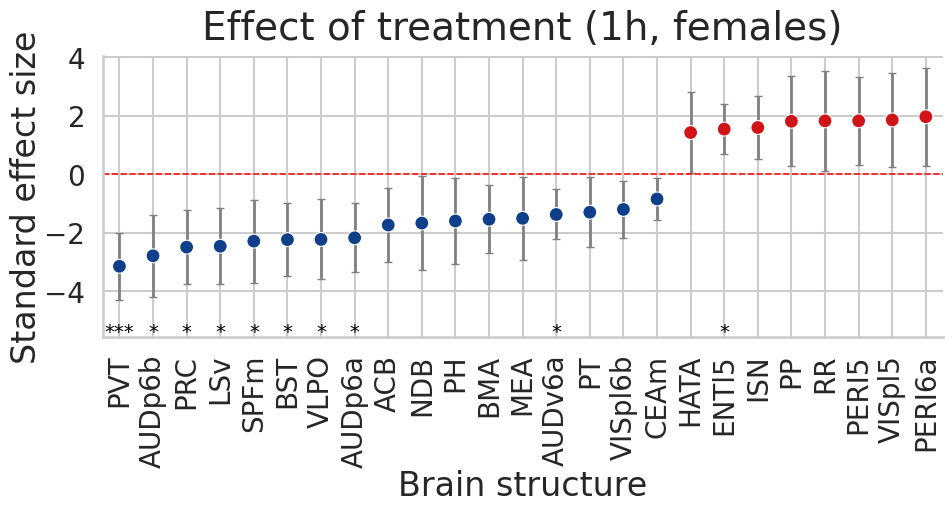

In [83]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# --- Prep
df["sign"] = np.where(df["effect"] >= 0, "positive", "negative")

order = list(df["structure"])
xpos = np.arange(len(df))

# --- Theme
sns.set_theme(style="whitegrid", context="talk")  # "talk" = larger fonts
plt.rcParams.update({
    "axes.labelsize": 24,
    "axes.titlesize": 28,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "font.weight": "regular"
})

# --- Figure
fig_w = 0.35 * len(df)
fig_h = 5
fig, ax = plt.subplots(figsize=(fig_w, fig_h))

# Scatter points
sns.scatterplot(
    x=xpos,
    y=df["effect"],
    hue=df["sign"],
    palette={"positive": "#cf1316", "negative": "#0f3e8a"},
    s=100,
    ax=ax,
    legend=False,
    zorder=3
)

# Vertical CI bars
for x, row in zip(xpos, df.itertuples()):
    ax.errorbar(
        x=x,
        y=row.effect,
        yerr=[[row.effect - row.lower_ci],
              [row.upper_ci - row.effect]],
        fmt="none",
        ecolor="gray",
        elinewidth=2,
        capsize=3,
        alpha=1,
        zorder=2
    )

# Reference line
ax.axhline(0, color="red", linestyle="--", lw=1.2, alpha=0.9)

# Labels
ax.set_xlabel("Brain structure", labelpad=1)
ax.set_ylabel("Standard effect size", labelpad=1)
ax.set_title("Effect of treatment (1h, females)", pad=12)

# Ticks
ax.set_xticks(xpos)
ax.set_xticklabels(order, rotation=90, ha="center")

# --- Layout tweaks
ax.set_xlim(-0.5, len(df) - 0.5)
sns.despine(left=False, bottom=False)
plt.tight_layout(pad=0.5)          # tighten figure padding
plt.subplots_adjust(left=0.02, right=0.98, bottom=0.32)  # reduce side margins

pval_col = "q"
def p_to_stars(p):
    if pd.isna(p): return ""
    if p < 1e-3:  return "***"
    if p < 1e-2:  return "**"
    if p < 0.05:  return "*"
    return ""

stars = df[pval_col].map(p_to_stars)

# Choose where that stars row lives (in data units)
ymin, ymax = ax.get_ylim()
rng = ymax - ymin
y_star = ymin - 0.08 * rng   # 8% below the current min (pick any value you like)

# Make sure the stars aren’t clipped
if y_star < ymin:
    ax.set_ylim(y_star - 0.02 * rng, ymax)  # tiny padding below

# Draw the star labels under each structure
for x, s in zip(xpos, stars):
    if s:
        ax.text(x, y_star, s, ha="center", va="center",
                fontsize=14, color="black", clip_on=False)

plt.savefig(
    os.path.join(SCREENSHOTS_FOLDER, "simple_effect_treatment_females_1h_d_marg.png"),
    dpi=300, bbox_inches="tight", transparent=True
)
plt.show()

In [84]:
structures_1h_female = df["structure"].to_list()
len(structures_1h_female)

25

## Main effect (Morphine vs Saline) 4h females

In [85]:
import numpy as np
from scipy import stats

with warnings.catch_warnings():
    warnings.simplefilter("ignore")

    betas = []
    beta_lower_cis = []
    beta_upper_cis = []
    effects = []
    lower_cis = []
    upper_cis = []
    pvals = []
    
    for abbr in contributing_regions_no_parents:
        sub = lmm_df_full[lmm_df_full["region"] == abbr].copy()
        
        sub["treatment"] = pd.Categorical(sub["treatment"], categories=["saline", "morphine"], ordered=True)
        sub["time"]      = pd.Categorical(sub["time"], categories=["1h", "4h"], ordered=True)
        sub["sex"]       = pd.Categorical(sub["sex"], categories=["M", "F"], ordered=True)
        
        
        # 3) Fit the mixed model: density ~ treatment * time * sex + (1 | mouse_id)
        md = smf.mixedlm("density ~ C(treatment) * C(time) * C(sex)", 
                         data=sub, 
                         groups=sub["mouse_id"])
        m = md.fit(reml=True, method="lbfgs")
    
        b_tr        = "C(treatment)[T.morphine]"
        b_tr_t4     = "C(treatment)[T.morphine]:C(time)[T.4h]"
        b_tr_f      = "C(treatment)[T.morphine]:C(sex)[T.F]"
        b_tr_t4_f   = "C(treatment)[T.morphine]:C(time)[T.4h]:C(sex)[T.F]"
        
        # --- Point estimate: sum of the four relevant betas ---
        est = float(
            m.params[b_tr] +
            m.params[b_tr_t4] +
            m.params[b_tr_f] +
            m.params[b_tr_t4_f]
        )
        
        # --- SE via variance-of-a-sum (include all pairwise covariances) ---
        cov = m.cov_params()
        v1 = cov.loc[b_tr,      b_tr]
        v2 = cov.loc[b_tr_t4,   b_tr_t4]
        v3 = cov.loc[b_tr_f,    b_tr_f]
        v4 = cov.loc[b_tr_t4_f, b_tr_t4_f]
        
        c12 = cov.loc[b_tr,      b_tr_t4]
        c13 = cov.loc[b_tr,      b_tr_f]
        c14 = cov.loc[b_tr,      b_tr_t4_f]
        c23 = cov.loc[b_tr_t4,   b_tr_f]
        c24 = cov.loc[b_tr_t4,   b_tr_t4_f]
        c34 = cov.loc[b_tr_f,    b_tr_t4_f]
        
        var_sum = v1 + v2 + v3 + v4 + 2*(c12 + c13 + c14 + c23 + c24 + c34)
        se = float(np.sqrt(var_sum))
        
        ci = (est - 1.96*se, est + 1.96*se)
        
        # Standardize to d-like
        var_u0 = float(m.cov_re.iloc[0, 0])      # random-intercept variance
        sd_marg = float(np.sqrt(m.scale + var_u0))
        d_marg = est / sd_marg
        ci_d_marg = (ci[0]/sd_marg, ci[1]/sd_marg)
        
        effects.append(d_marg)
        lower_cis.append(ci_d_marg[0])
        upper_cis.append(ci_d_marg[1])
    
        fe = m.fe_params  # fixed effects only
        # Vb = m.cov_params().loc[fe.index, fe.index]
        
        w = pd.Series(0.0, index=fe.index)  
        w["C(treatment)[T.morphine]"] += 1.0
        w["C(treatment)[T.morphine]:C(time)[T.4h]"] += 1.0
        w["C(treatment)[T.morphine]:C(sex)[T.F]"] += 1.0
        w["C(treatment)[T.morphine]:C(time)[T.4h]:C(sex)[T.F]"] += 1.0
        
        tt = m.t_test(w.values[None, :])   # shape (1, k_fe)
        pval  = float(tt.pvalue)
    
        betas.append(est)
        beta_lower_cis.append(ci[0])
        beta_upper_cis.append(ci[1])
        pvals.append(pval)
    
    results_df = pd.DataFrame()
    results_df['structure'] = contributing_regions_no_parents
    results_df['beta'] = betas
    results_df['beta_lower_ci'] = beta_lower_cis
    results_df['beta_upper_ci'] = beta_upper_cis
    results_df['effect'] = effects
    results_df['lower_ci'] = lower_cis
    results_df['upper_ci'] = upper_cis
    results_df['abs_effect'] = np.abs(results_df['effect'].to_list())
    results_df['p'] = pvals
    reject, pvals_corrected, alphacSidak, alphacBonf = multipletests(
        pvals, alpha=0.05, method="fdr_bh"  # Benjamini-Hochberg FDR
    )
    results_df['q'] = pvals_corrected
    results_df.sort_values('abs_effect', ascending=False, inplace=True)

In [86]:
d_thresh = 0.8
results_df_large = results_df[results_df['abs_effect'] >= d_thresh]
positive_effects = results_df_large[results_df_large['effect'] > 0]
positive_effects = positive_effects[positive_effects["lower_ci"] > 0]
positive_effects.shape

(17, 10)

In [87]:
negative_effects = results_df[results_df['effect'] < 0]
negative_effects = negative_effects[negative_effects["upper_ci"] < 0]
negative_effects.shape

(0, 10)

In [88]:
df = pd.concat([positive_effects.copy(), negative_effects.copy()])
df = df.sort_values("effect").reset_index(drop=True)

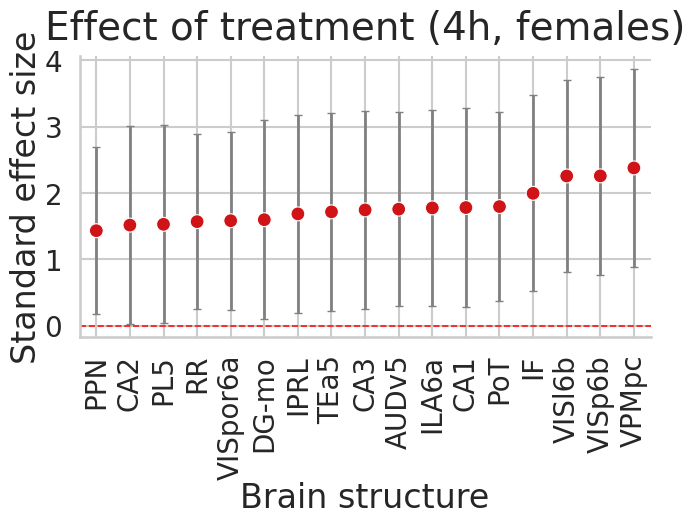

In [89]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# --- Prep
df = pd.concat([positive_effects.copy(), negative_effects.copy()])
df = df.sort_values("effect").reset_index(drop=True)
df["sign"] = np.where(df["effect"] >= 0, "positive", "negative")

order = list(df["structure"])
xpos = np.arange(len(df))

# --- Theme
sns.set_theme(style="whitegrid", context="talk")  # "talk" = larger fonts
plt.rcParams.update({
    "axes.labelsize": 24,
    "axes.titlesize": 28,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "font.weight": "regular"
})

# --- Figure
fig_w = 0.35 * len(df)
fig_h = 5
fig, ax = plt.subplots(figsize=(fig_w, fig_h))

# Scatter points
sns.scatterplot(
    x=xpos,
    y=df["effect"],
    hue=df["sign"],
    palette={"positive": "#cf1316", "negative": "#0f3e8a"},
    s=100,
    ax=ax,
    legend=False,
    zorder=3
)

# Vertical CI bars
for x, row in zip(xpos, df.itertuples()):
    ax.errorbar(
        x=x,
        y=row.effect,
        yerr=[[row.effect - row.lower_ci],
              [row.upper_ci - row.effect]],
        fmt="none",
        ecolor="gray",
        elinewidth=2,
        capsize=3,
        alpha=1,
        zorder=2
    )

# Reference line
ax.axhline(0, color="red", linestyle="--", lw=1.2, alpha=0.9)

# Labels
ax.set_xlabel("Brain structure", labelpad=1)
ax.set_ylabel("Standard effect size", labelpad=1)
ax.set_title("Effect of treatment (4h, females)", pad=12)

# Ticks
ax.set_xticks(xpos)
ax.set_xticklabels(order, rotation=90, ha="center")

# --- Layout tweaks
ax.set_xlim(-0.5, len(df) - 0.5)
sns.despine(left=False, bottom=False)
plt.tight_layout(pad=0.5)          # tighten figure padding
plt.subplots_adjust(left=0.02, right=0.98, bottom=0.32)  # reduce side margins

plt.savefig(
    os.path.join(SCREENSHOTS_FOLDER, "simple_effect_treatment_females_4h_d_marg.png"),
    dpi=300, bbox_inches="tight", transparent=True
)
plt.show()

In [90]:
structures_4h_female = df["structure"].to_list()
len(structures_4h_female)

17

In [91]:
all_morphine_responsive_structures = set(structures_1h_male + structures_4h_male + structures_1h_female + structures_4h_female)
len(all_morphine_responsive_structures)

132

In [92]:
print(all_morphine_responsive_structures)

{'ACAv2/3', 'VPMpc', 'PIL', 'MPN', 'CUN', 'APN', 'AUDpo5', 'DMX', 'EPd', 'HATA', 'VISam6b', 'ENTl3', 'VISpl5', 'MOs6a', 'CLA', 'AIp6a', 'VISp6a', 'PA', 'PMd', 'AUDpo6b', 'PRC', 'MMme', 'LDT', 'LT', 'PVT', 'BLAp', 'SCdg', 'MT', 'VISam5', 'DG-mo', 'CA2', 'SI', 'SSs5', 'POL', 'PG', 'ENTm5', 'CEAm', 'ECT6a', 'AUDv5', 'TEa6a', 'PL6b', 'MOp5', 'SSp-bfd6b', 'AUDv6a', 'SUT', 'VISpm5', 'VISli5', 'SNr', 'PCG', 'VISp5', 'ACAv6b', 'SSp-n1', 'DR', 'AUDp6a', 'CL', 'ENTl6a', 'MEA', 'FC', 'ProS', 'PH', 'COApm', 'SSp-bfd5', 'LHA', 'VISC5', 'SSp-un4', 'VISa5', 'VISpor6b', 'TEa6b', 'ORBm6a', 'NTS', 'ACAv6a', 'VISpor6a', 'PVa', 'IPI', 'PERI6a', 'BST', 'VISli6a', 'ACAv5', 'CA3', 'RR', 'SSs6a', 'SSs4', 'VTA', 'ILA6a', 'BMA', 'ACAd6a', 'TEa5', 'CA1', 'RSPagl6a', 'PP', 'CENT3', 'MGm', 'AUDd5', 'PL5', 'VISpl6a', 'VISpor5', 'RSPv6a', 'EPv', 'CENT2', 'AUDp6b', 'PVH', 'SSp-ul5', 'ACB', 'PRP', 'DTN', 'VISpl6b', 'P5', 'PERI5', 'SSp-un5', 'IPRL', 'PoT', 'IF', 'SLD', 'LSv', 'AIv6a', 'VISp6b', 'PPN', 'PL6a', 'VLPO', '

In [93]:
large_structures = ['Isocortex', 'CTXsp', 'HPF', 'OLF', 'HY', 'MB', 'P', 'PAL', 'STR', 'TH', 'MY', 'CB']
major_regions = [get_major_parent(x) for x in all_morphine_responsive_structures]

morphine_resp_df = pd.DataFrame()
morphine_resp_df["region"] = list(all_morphine_responsive_structures)
morphine_resp_df["parent"] = major_regions
# from IPython.display import display, HTML
# display(HTML(morphine_resp_df.to_html()))

grouped = morphine_resp_df.groupby('parent')
for parent, group in grouped:
    print(f"\nGroup: {parent}")
    print(len(group["region"].to_list()))
    print(sorted(group["region"].to_list()))


Group: CB
2
['CENT2', 'CENT3']

Group: CTXsp
7
['BLAp', 'BMA', 'CLA', 'EPd', 'EPv', 'LA', 'PA']

Group: HPF
12
['CA1', 'CA2', 'CA3', 'DG-mo', 'ENTl3', 'ENTl5', 'ENTl6a', 'ENTm5', 'ENTm6', 'FC', 'HATA', 'ProS']

Group: HY
9
['LHA', 'MMme', 'MPN', 'PH', 'PMd', 'PVH', 'PVHd', 'PVa', 'VLPO']

Group: Isocortex
58
['ACAd6a', 'ACAv2/3', 'ACAv5', 'ACAv6a', 'ACAv6b', 'AIp6a', 'AIv6a', 'AUDd5', 'AUDp6a', 'AUDp6b', 'AUDpo5', 'AUDpo6b', 'AUDv5', 'AUDv6a', 'ECT6a', 'ILA6a', 'MOp5', 'MOs6a', 'ORBm6a', 'PERI5', 'PERI6a', 'PL5', 'PL6a', 'PL6b', 'RSPagl1', 'RSPagl6a', 'RSPv6a', 'SSp-bfd5', 'SSp-bfd6b', 'SSp-n1', 'SSp-ul4', 'SSp-ul5', 'SSp-un4', 'SSp-un5', 'SSs4', 'SSs5', 'SSs6a', 'TEa5', 'TEa6a', 'TEa6b', 'VISC5', 'VISa5', 'VISam5', 'VISam6b', 'VISl6b', 'VISli5', 'VISli6a', 'VISp5', 'VISp6a', 'VISp6b', 'VISpl5', 'VISpl6a', 'VISpl6b', 'VISpm5', 'VISpor5', 'VISpor6a', 'VISpor6b', 'VISrl5']

Group: MB
14
['APN', 'CUN', 'DR', 'IF', 'IPI', 'IPRL', 'LT', 'MT', 'PPN', 'PRC', 'RR', 'SCdg', 'SNr', 'VTA']

Grou

In [94]:
morphine_structures_1h = structures_1h_male + structures_1h_female
print(morphine_structures_1h)

['EPd', 'PP', 'VISp5', 'AUDpo6b', 'ENTl5', 'VISpl6a', 'ENTm6', 'ACAv6b', 'ProS', 'VISli5', 'ECT6a', 'DG-mo', 'CLA', 'AUDd5', 'ENTm5', 'AIv6a', 'EPv', 'VISp6a', 'TEa6a', 'SSs5', 'SCdg', 'PERI6a', 'APN', 'AIp6a', 'SSs6a', 'AUDv5', 'ENTl6a', 'TEa6b', 'AUDpo5', 'VISpl6b', 'VISpl5', 'ACB', 'LA', 'PIL', 'BMA', 'VISpor5', 'MGm', 'RSPagl6a', 'VISam6b', 'AUDv6a', 'BLAp', 'PRC', 'VISpor6b', 'CEAm', 'ACAv6a', 'LHA', 'VISpm5', 'DR', 'VISpor6a', 'VISrl5', 'PMd', 'VISam5', 'CA1', 'CUN', 'TEa5', 'VISa5', 'MT', 'CA3', 'PA', 'POL', 'COApm', 'LT', 'CENT3', 'MEA', 'PH', 'CL', 'SNr', 'MMme', 'PVH', 'PVHd', 'RSPv6a', 'CENT2', 'VISC5', 'SSp-bfd5', 'P5', 'CA2', 'ENTl3', 'VISli6a', 'SSp-bfd6b', 'RSPagl1', 'SSp-n1', 'IPI', 'PVT', 'AUDp6b', 'PRC', 'LSv', 'SPFm', 'BST', 'VLPO', 'AUDp6a', 'ACB', 'NDB', 'PH', 'BMA', 'MEA', 'AUDv6a', 'PT', 'VISpl6b', 'CEAm', 'HATA', 'ENTl5', 'ISN', 'PP', 'RR', 'PERI5', 'VISpl5', 'PERI6a']


In [95]:
morphine_structures_4h = structures_4h_male + structures_4h_female
print(morphine_structures_4h)

['FC', 'PL6b', 'PVa', 'NTS', 'DMX', 'SSp-ul5', 'SI', 'SSp-un4', 'SSp-bfd5', 'SSp-un5', 'VTA', 'ACAv6a', 'SSp-ul4', 'ORBm6a', 'VISli6a', 'PL5', 'MOp5', 'MOs6a', 'SSs4', 'NDB', 'ACAv2/3', 'ACAv5', 'PG', 'MPN', 'ACAd6a', 'SUT', 'AUDd5', 'VISpl6a', 'PL6a', 'VISC5', 'SLD', 'DTN', 'SSs5', 'LDT', 'PRP', 'PCG', 'SLC', 'PPN', 'CA2', 'PL5', 'RR', 'VISpor6a', 'DG-mo', 'IPRL', 'TEa5', 'CA3', 'AUDv5', 'ILA6a', 'CA1', 'PoT', 'IF', 'VISl6b', 'VISp6b', 'VPMpc']


In [96]:
SCREENSHOTS_FOLDER = "brainrender/response_to_review"
if not os.path.exists(SCREENSHOTS_FOLDER):
    os.makedirs(SCREENSHOTS_FOLDER)
import brainrender
brainrender.settings.vsettings.screenshot_transparent_background = True
from brainrender import Scene
from brainrender._colors import map_color
alpha = 0.5

class CustomScene(Scene):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

    def _make_axes(self):
        return {}

brainrender.settings.SHADER_STYLE = "glossy"
alpha = 0.4

scene1 = CustomScene(screenshots_folder=SCREENSHOTS_FOLDER, atlas_name="allen_mouse_10um")
for region in set(structures_1h_male)-set(structures_4h_male)-set(structures_1h_female)-set(structures_4h_female):
    scene1.add_brain_region(
    region,
    alpha=alpha,
    color="#377EB8" # "blue"
)
for region in set(structures_4h_male)-set(structures_1h_female)-set(structures_4h_female):
    scene1.add_brain_region(
    region,
    alpha=alpha,
    color="#4DAF4A"  # "green"
)
for region in set(structures_1h_female)-set(structures_4h_female):
    scene1.add_brain_region(
    region,
    alpha=alpha,
    color="#E41A1C"  # "red"
)
for region in structures_4h_female:
    scene1.add_brain_region(
    region,
    alpha=alpha,
    color="#E6AB02"  # "gold"
) 
scene1.slice('sagittal')
scene1.render(interactive=False, zoom=1)
scene1.screenshot(name="morphine_responsive_structures")


Saving new screenshot at morphine_responsive_structures.png

'brainrender/response_to_review/morphine_responsive_structures.png'

In [97]:
structures_1h = set(structures_1h_male + structures_1h_female)
structures_4h = set(structures_4h_male + structures_4h_female)
len(structures_1h), len(structures_4h)

(95, 53)

In [98]:
len(structures_1h.intersection(structures_4h))

16

In [99]:
structures_1h.intersection(structures_4h)


{
    'AUDv5',
    'VISC5',
    'CA1',
    'AUDd5',
    'VISli6a',
    'SSs5',
    'CA3',
    'RR',
    'VISpl6a',
    'SSp-bfd5',
    'ACAv6a',
    'DG-mo',
    'CA2',
    'VISpor6a',
    'TEa5',
    'NDB'
}

In [100]:
structures_4h.difference(structures_1h)


{
    'ACAv2/3',
    'SSp-un4',
    'VPMpc',
    'SI',
    'MPN',
    'DMX',
    'PG',
    'SSp-ul5',
    'ORBm6a',
    'PRP',
    'NTS',
    'DTN',
    'PVa',
    'MOs6a',
    'PL6b',
    'ACAv5',
    'SSp-un5',
    'MOp5',
    'IPRL',
    'PoT',
    'IF',
    'SLD',
    'SSs4',
    'VTA',
    'ILA6a',
    'SUT',
    'ACAd6a',
    'VISp6b',
    'PPN',
    'PL6a',
    'SSp-ul4',
    'LDT',
    'PCG',
    ... +4
}

In [101]:
structures_1h.difference(structures_4h)


{
    'PIL',
    'CUN',
    'APN',
    'AUDpo5',
    'HATA',
    'EPd',
    'VISam6b',
    'ENTl3',
    'VISpl5',
    'CLA',
    'AIp6a',
    'VISp6a',
    'PA',
    'PMd',
    'AUDpo6b',
    'PRC',
    'MMme',
    'LT',
    'PVT',
    'BLAp',
    'SCdg',
    'MT',
    'VISam5',
    'POL',
    'ENTm5',
    'CEAm',
    'ECT6a',
    'TEa6a',
    'SSp-bfd6b',
    'AUDv6a',
    'VISpm5',
    'VISli5',
    'SNr',
    ... +46
}

## Interaction effect treatment:time for males (time difference)

In [102]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")

    betas = []
    beta_lower_cis = []
    beta_upper_cis = []
    effects = []
    lower_cis = []
    upper_cis = []
    pvals = []
    
    for abbr in contributing_regions_no_parents:
        sub = lmm_df_full[lmm_df_full["region"] == abbr].copy()
        
        sub["treatment"] = pd.Categorical(sub["treatment"], categories=["saline", "morphine"], ordered=True)
        sub["time"]      = pd.Categorical(sub["time"], categories=["1h", "4h"], ordered=True)
        sub["sex"]       = pd.Categorical(sub["sex"], categories=["M", "F"], ordered=True)
        
        
        # 3) Fit the mixed model: density ~ treatment * time * sex + (1 | mouse_id)
        md = smf.mixedlm("density ~ C(treatment) * C(time) * C(sex)", 
                         data=sub, 
                         groups=sub["mouse_id"])
        m = md.fit(reml=True, method="lbfgs")
    
        # Check: print(m.params.index.tolist())
        b_tr_name   = "C(treatment)[T.morphine]:C(time)[T.4h]"
        
        # Point estimate = sum of betas
        beta = m.params[b_tr_name]
        se_beta = m.bse[b_tr_name]
        beta_lcl = beta - 1.96*se_beta
        beta_ucl = beta + 1.96*se_beta
       
        # Standardize to marginal Cohen's d
        sigma_eps = float(np.sqrt(m.scale))  # residual SD
        var_u0 = float(m.cov_re.iloc[0, 0])  # random-intercept variance
        sd_marg = float(np.sqrt(m.scale + var_u0))  # marginal SD (Random intercept model)
        
        d_marg = beta / sd_marg
        se_d_marg = se_beta / sd_marg
        ci_d = (d_marg - 1.96*se_d_marg, d_marg + 1.96*se_d_marg)
    
        effects.append(d_marg)
        lower_cis.append(ci_d[0])
        upper_cis.append(ci_d[1])
        betas.append(beta)
        beta_lower_cis.append(beta_lcl)
        beta_upper_cis.append(beta_ucl)
        pvals.append(m.pvalues[b_tr_name])
    
    results_df = pd.DataFrame()
    results_df['structure'] = contributing_regions_no_parents
    results_df['beta'] = betas
    results_df['beta_lower_ci'] = beta_lower_cis
    results_df['beta_upper_ci'] = beta_upper_cis
    results_df['effect'] = effects
    results_df['lower_ci'] = lower_cis
    results_df['upper_ci'] = upper_cis
    results_df['abs_effect'] = np.abs(results_df['effect'].to_list())
    results_df['p'] = pvals
    reject, pvals_corrected, alphacSidak, alphacBonf = multipletests(
        pvals, alpha=0.05, method="fdr_bh"  # Benjamini-Hochberg FDR
    )
    results_df['q'] = pvals_corrected
    results_df.sort_values('abs_effect', ascending=False, inplace=True)

In [103]:
results_df[results_df['q'] < 0.05]

,structure,beta,beta_lower_ci,beta_upper_ci,effect,lower_ci,upper_ci,abs_effect,p,q
173,PRP,178.250928,95.618933,260.882923,2.624468,1.40784,3.841095,2.624468,2.357303e-05,3.253078e-03
29,SLC,1391.486497,932.431309,1850.541684,1.858476,1.24536,2.471593,1.858476,2.830377e-09,7.811841e-07


In [104]:
d_thresh = 0.8
results_df_large = results_df[results_df['abs_effect'] >= d_thresh]
positive_effects = results_df_large[results_df_large['effect'] > 0]
positive_effects = positive_effects[positive_effects["lower_ci"] > 0]
positive_effects.shape

(12, 10)

In [105]:
negative_effects = results_df[results_df['effect'] < 0]
negative_effects = negative_effects[negative_effects["upper_ci"] < 0]
negative_effects.shape

(12, 10)

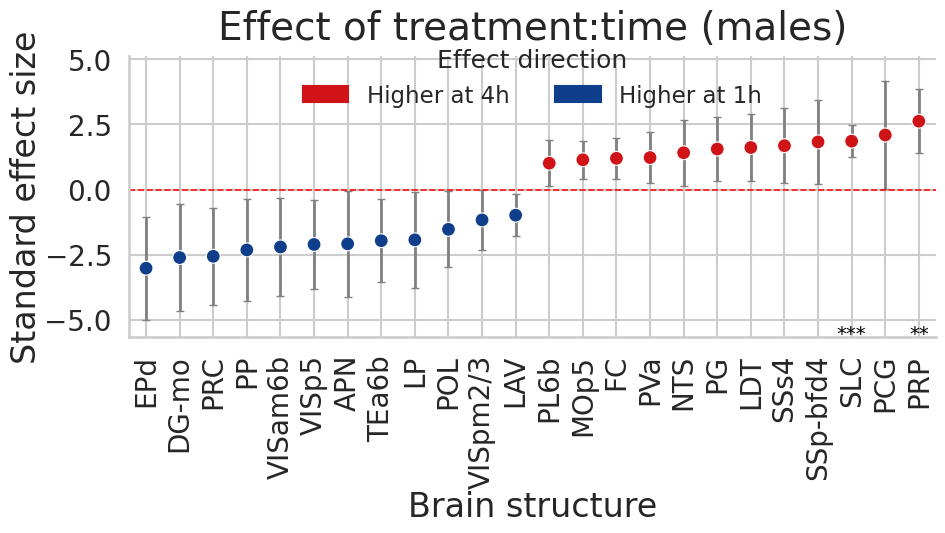

In [106]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# --- Prep
df = pd.concat([positive_effects.copy(), negative_effects.copy()])
df = df.sort_values("effect").reset_index(drop=True)
df["sign"] = np.where(df["effect"] >= 0, "positive", "negative")

order = list(df["structure"])
xpos = np.arange(len(df))

# --- Theme
sns.set_theme(style="whitegrid", context="talk")  # "talk" = larger fonts
plt.rcParams.update({
    "axes.labelsize": 24,
    "axes.titlesize": 28,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "font.weight": "regular"
})

# --- Figure
fig_w = 0.35 * len(df)
fig_h = 5
fig, ax = plt.subplots(figsize=(fig_w, fig_h))

# Scatter points
sns.scatterplot(
    x=xpos,
    y=df["effect"],
    hue=df["sign"],
    palette={"positive": "#cf1316", "negative": "#0f3e8a"},
    s=100,
    ax=ax,
    legend=False,
    zorder=3
)

# Vertical CI bars
for x, row in zip(xpos, df.itertuples()):
    ax.errorbar(
        x=x,
        y=row.effect,
        yerr=[[row.effect - row.lower_ci],
              [row.upper_ci - row.effect]],
        fmt="none",
        ecolor="gray",
        elinewidth=2,
        capsize=3,
        alpha=1,
        zorder=2
    )

# Reference line
ax.axhline(0, color="red", linestyle="--", lw=1.2, alpha=0.9)

# Labels
ax.set_xlabel("Brain structure", labelpad=1)
ax.set_ylabel("Standard effect size", labelpad=1)
ax.set_title("Effect of treatment:time (males)", pad=12)

# Ticks
ax.set_xticks(xpos)
ax.set_xticklabels(order, rotation=90, ha="center")

legend_patches = [
    mpatches.Patch(color="#cf1316", label="Higher at 4h"),
    mpatches.Patch(color="#0f3e8a", label="Higher at 1h"),
]

ax.legend(
    handles=legend_patches,
    title="Effect direction",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.1),
    ncol=2,
    frameon=False
)

# --- Layout tweaks
ax.set_xlim(-0.5, len(df) - 0.5)
sns.despine(left=False, bottom=False)
plt.tight_layout(pad=0.5)          # tighten figure padding
plt.subplots_adjust(left=0.02, right=0.98, bottom=0.32)  # reduce side margins

pval_col = "q"
def p_to_stars(p):
    if pd.isna(p): return ""
    if p < 1e-3:  return "***"
    if p < 1e-2:  return "**"
    if p < 0.05:  return "*"
    return ""

stars = df[pval_col].map(p_to_stars)

# Choose where that stars row lives (in data units)
ymin, ymax = ax.get_ylim()
rng = ymax - ymin
y_star = ymin - 0.01 * rng   # 8% below the current min (pick any value you like)

# Make sure the stars aren’t clipped
if y_star < ymin:
    ax.set_ylim(y_star - 0.01 * rng, ymax + 0.05 * rng)  # tiny padding below

# Draw the star labels under each structure
for x, s in zip(xpos, stars):
    if s:
        ax.text(x, y_star, s, ha="center", va="center",
                fontsize=14, color="black", clip_on=False)

plt.savefig(
    os.path.join(SCREENSHOTS_FOLDER, "effect_treatment_time_males_d_marg.png"),
    dpi=300, bbox_inches="tight", transparent=True
)
plt.show()

In [107]:
structures_time_diff_males = df["structure"].to_list()
len(structures_time_diff_males)

24

## Interaction effect treatment:time for females (time difference)

In [108]:
import numpy as np
from scipy import stats

with warnings.catch_warnings():
    warnings.simplefilter("ignore")

    betas = []
    beta_lower_cis = []
    beta_upper_cis = []
    effects = []
    lower_cis = []
    upper_cis = []
    pvals = []
    
    for abbr in contributing_regions_no_parents:
        sub = lmm_df_full[lmm_df_full["region"] == abbr].copy()
        
        sub["treatment"] = pd.Categorical(sub["treatment"], categories=["saline", "morphine"], ordered=True)
        sub["time"]      = pd.Categorical(sub["time"], categories=["1h", "4h"], ordered=True)
        sub["sex"]       = pd.Categorical(sub["sex"], categories=["M", "F"], ordered=True)
        
        
        # 3) Fit the mixed model: density ~ treatment * time * sex + (1 | mouse_id)
        md = smf.mixedlm("density ~ C(treatment) * C(time) * C(sex)", 
                         data=sub, 
                         groups=sub["mouse_id"])
        m = md.fit(reml=True, method="lbfgs")
        
        b_tr_t4      = "C(treatment)[T.morphine]:C(time)[T.4h]"
        b_tr_t4_sexF = "C(treatment)[T.morphine]:C(time)[T.4h]:C(sex)[T.F]"
        
        # Point estimate = sum of the two betas
        est = float(m.params[b_tr_t4] + m.params[b_tr_t4_sexF])
        
        # SE via variance-of-a-sum: Var(X+Y) = Var(X) + Var(Y) + 2*Cov(X,Y)
        cov = m.cov_params()
        v1  = cov.loc[b_tr_t4, b_tr_t4]
        v2  = cov.loc[b_tr_t4_sexF, b_tr_t4_sexF]
        c12 = cov.loc[b_tr_t4, b_tr_t4_sexF]
        se  = float(np.sqrt(v1 + v2 + 2*c12))
    
        ci = (est - 1.96*se, est + 1.96*se)
       
        # Standardize to marginal Cohen's d
        sigma_eps = float(np.sqrt(m.scale))  # residual SD
        var_u0 = float(m.cov_re.iloc[0, 0])  # random-intercept variance
        sd_marg = float(np.sqrt(m.scale + var_u0))  # marginal SD (Random intercept model)
        
        d_marg = est / sd_marg
        se_d_marg = se / sd_marg
        
        ci_d = (d_marg - 1.96*se_d_marg, d_marg + 1.96*se_d_marg)
    
        fe_names = m.fe_params.index
        w = pd.Series(0.0, index=fe_names) 
        w["C(treatment)[T.morphine]:C(time)[T.4h]"] = 1.0
        w["C(treatment)[T.morphine]:C(time)[T.4h]:C(sex)[T.F]"] = 1.0
        tt = m.t_test(w.values[None, :])
        pval = float(tt.pvalue)
        
        effects.append(d_marg)
        lower_cis.append(ci_d[0])
        upper_cis.append(ci_d[1])
        betas.append(est)
        beta_lower_cis.append(ci[0])
        beta_upper_cis.append(ci[1])
        pvals.append(pval)
    
    results_df = pd.DataFrame()
    results_df['structure'] = contributing_regions_no_parents
    results_df['beta'] = betas
    results_df['beta_lower_ci'] = beta_lower_cis
    results_df['beta_upper_ci'] = beta_upper_cis
    results_df['effect'] = effects
    results_df['lower_ci'] = lower_cis
    results_df['upper_ci'] = upper_cis
    results_df['abs_effect'] = np.abs(results_df['effect'].to_list())
    results_df['p'] = pvals
    reject, pvals_corrected, alphacSidak, alphacBonf = multipletests(
        pvals, alpha=0.05, method="fdr_bh"  # Benjamini-Hochberg FDR
    )
    results_df['q'] = pvals_corrected
    results_df.sort_values('abs_effect', ascending=False, inplace=True)

In [109]:
results_df[results_df['q'] < 0.05]

,structure,beta,beta_lower_ci,beta_upper_ci,effect,lower_ci,upper_ci,abs_effect,p,q
133,PVT,1886.269622,1080.955564,2691.58368,3.811227,2.184082,5.438372,3.811227,0.000004,0.001218


In [110]:
d_thresh = 0.8
results_df_large = results_df[results_df['abs_effect'] >= d_thresh]
positive_effects = results_df_large[results_df_large['effect'] > 0]
positive_effects = positive_effects[positive_effects["lower_ci"] > 0]
positive_effects.shape

(23, 10)

In [111]:
negative_effects = results_df[results_df['effect'] < 0]
negative_effects = negative_effects[negative_effects["upper_ci"] < 0]
negative_effects.shape

(0, 10)

In [112]:
df = pd.concat([positive_effects.copy(), negative_effects.copy()])
df = df.sort_values("effect", ascending=False).reset_index(drop=True)

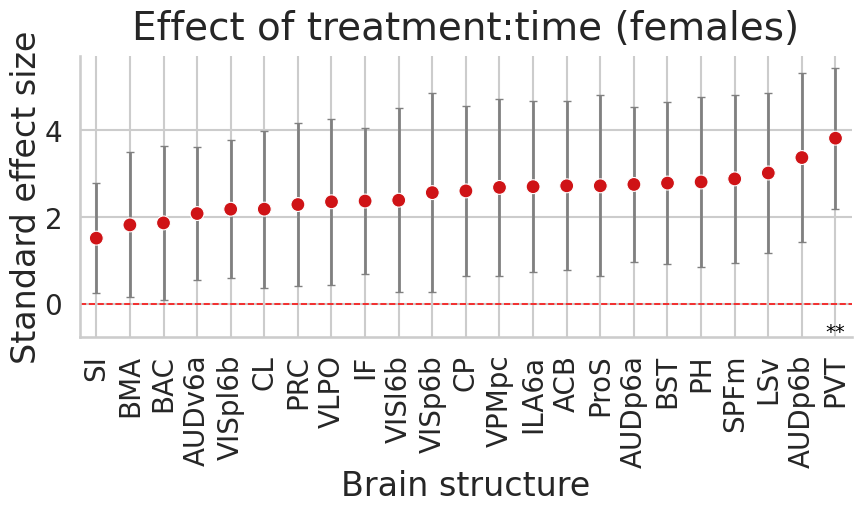

In [113]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# --- Prep
df = pd.concat([positive_effects.copy(), negative_effects.copy()])
df = df.sort_values("effect").reset_index(drop=True)
df["sign"] = np.where(df["effect"] >= 0, "positive", "negative")

order = list(df["structure"])
xpos = np.arange(len(df))

# --- Theme
sns.set_theme(style="whitegrid", context="talk")  # "talk" = larger fonts
plt.rcParams.update({
    "axes.labelsize": 24,
    "axes.titlesize": 28,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "font.weight": "regular"
})

# --- Figure
fig_w = 0.35 * len(df)
fig_h = 5
fig, ax = plt.subplots(figsize=(fig_w, fig_h))

# Scatter points
sns.scatterplot(
    x=xpos,
    y=df["effect"],
    hue=df["sign"],
    palette={"positive": "#cf1316", "negative": "#0f3e8a"},
    s=100,
    ax=ax,
    legend=False,
    zorder=3
)

# Vertical CI bars
for x, row in zip(xpos, df.itertuples()):
    ax.errorbar(
        x=x,
        y=row.effect,
        yerr=[[row.effect - row.lower_ci],
              [row.upper_ci - row.effect]],
        fmt="none",
        ecolor="gray",
        elinewidth=2,
        capsize=3,
        alpha=1,
        zorder=2
    )

# Reference line
ax.axhline(0, color="red", linestyle="--", lw=1.2, alpha=0.9)

# Labels
ax.set_xlabel("Brain structure", labelpad=1)
ax.set_ylabel("Standard effect size", labelpad=1)
ax.set_title("Effect of treatment:time (females)", pad=12)

# Ticks
ax.set_xticks(xpos)
ax.set_xticklabels(order, rotation=90, ha="center")

# --- Layout tweaks
ax.set_xlim(-0.5, len(df) - 0.5)
sns.despine(left=False, bottom=False)
plt.tight_layout(pad=0.5)          # tighten figure padding
plt.subplots_adjust(left=0.02, right=0.98, bottom=0.32)  # reduce side margins

pval_col = "q"
def p_to_stars(p):
    if pd.isna(p): return ""
    if p < 1e-3:  return "***"
    if p < 1e-2:  return "**"
    if p < 0.05:  return "*"
    return ""

stars = df[pval_col].map(p_to_stars)

# Choose where that stars row lives (in data units)
ymin, ymax = ax.get_ylim()
rng = ymax - ymin
y_star = ymin - 0.08 * rng   # 8% below the current min (pick any value you like)

# Make sure the stars aren’t clipped
if y_star < ymin:
    ax.set_ylim(y_star - 0.02 * rng, ymax)  # tiny padding below

# Draw the star labels under each structure
for x, s in zip(xpos, stars):
    if s:
        ax.text(x, y_star, s, ha="center", va="center",
                fontsize=14, color="black", clip_on=False)

plt.savefig(
    os.path.join(SCREENSHOTS_FOLDER, "effect_treatment_time_females_d_marg.png"),
    dpi=300, bbox_inches="tight", transparent=True
)
plt.show()

In [114]:
structures_time_diff_females = df["structure"].to_list()
len(structures_time_diff_females)

23

In [115]:
structures_time_diff = structures_time_diff_males + structures_time_diff_females
print(structures_time_diff)

['EPd', 'DG-mo', 'PRC', 'PP', 'VISam6b', 'VISp5', 'APN', 'TEa6b', 'LP', 'POL', 'VISpm2/3', 'LAV', 'PL6b', 'MOp5', 'FC', 'PVa', 'NTS', 'PG', 'LDT', 'SSs4', 'SSp-bfd4', 'SLC', 'PCG', 'PRP', 'SI', 'BMA', 'BAC', 'AUDv6a', 'VISpl6b', 'CL', 'PRC', 'VLPO', 'IF', 'VISl6b', 'VISp6b', 'CP', 'VPMpc', 'ILA6a', 'ACB', 'ProS', 'AUDp6a', 'BST', 'PH', 'SPFm', 'LSv', 'AUDp6b', 'PVT']


In [116]:
large_structures = ['Isocortex', 'CTXsp', 'HPF', 'OLF', 'HY', 'MB', 'P', 'PAL', 'STR', 'TH', 'MY', 'CB']
major_regions = [get_major_parent(x) for x in structures_time_diff]

time_diff_df = pd.DataFrame()
time_diff_df["region"] = list(structures_time_diff)
time_diff_df["parent"] = major_regions
# from IPython.display import display, HTML
# display(HTML(morphine_resp_df.to_html()))

grouped = time_diff_df.groupby('parent')
for parent, group in grouped:
    print(f"\nGroup: {parent}")
    print(len(group["region"].to_list()))
    print(sorted(group["region"].to_list()))


Group: CTXsp
2
['BMA', 'EPd']

Group: HPF
3
['DG-mo', 'FC', 'ProS']

Group: HY
3
['PH', 'PVa', 'VLPO']

Group: Isocortex
15
['AUDp6a', 'AUDp6b', 'AUDv6a', 'ILA6a', 'MOp5', 'PL6b', 'SSp-bfd4', 'SSs4', 'TEa6b', 'VISam6b', 'VISl6b', 'VISp5', 'VISp6b', 'VISpl6b', 'VISpm2/3']

Group: MB
4
['APN', 'IF', 'PRC', 'PRC']

Group: MY
3
['LAV', 'NTS', 'PRP']

Group: P
4
['LDT', 'PCG', 'PG', 'SLC']

Group: PAL
3
['BAC', 'BST', 'SI']

Group: STR
3
['ACB', 'CP', 'LSv']

Group: TH
7
['CL', 'LP', 'POL', 'PP', 'PVT', 'SPFm', 'VPMpc']


In [117]:
import brainrender
brainrender.settings.vsettings.screenshot_transparent_background = True
from brainrender import Scene
from brainrender._colors import map_color
alpha = 0.5

class CustomScene(Scene):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

    def _make_axes(self):
        return {}

brainrender.settings.SHADER_STYLE = "glossy"
alpha = 0.4

scene1 = CustomScene(screenshots_folder=SCREENSHOTS_FOLDER, atlas_name="allen_mouse_10um")
for region in set(structures_time_diff_males)-set(structures_time_diff_females):
    scene1.add_brain_region(
    region,
    alpha=alpha,
    color="#377EB8" # "blue"
)
for region in structures_time_diff_females:
    scene1.add_brain_region(
    region,
    alpha=alpha,
    color="#ED3BCA"  # "pink"
)

scene1.slice('sagittal')
scene1.render(interactive=False, zoom=1)
scene1.screenshot(name="structures_w_time_differences")

Saving new screenshot at structures_w_time_differences.png

'brainrender/response_to_review/structures_w_time_differences.png'

## Interaction effect treatment:sex at 1h (sex difference)

In [118]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")

    betas = []
    beta_lower_cis = []
    beta_upper_cis = []
    effects = []
    lower_cis = []
    upper_cis = []
    pvals = []
    
    for abbr in contributing_regions_no_parents:
        sub = lmm_df_full[lmm_df_full["region"] == abbr].copy()
        
        sub["treatment"] = pd.Categorical(sub["treatment"], categories=["saline", "morphine"], ordered=True)
        sub["time"]      = pd.Categorical(sub["time"], categories=["1h", "4h"], ordered=True)
        sub["sex"]       = pd.Categorical(sub["sex"], categories=["M", "F"], ordered=True)
        
        
        # 3) Fit the mixed model: density ~ treatment * time * sex + (1 | mouse_id)
        md = smf.mixedlm("density ~ C(treatment) * C(time) * C(sex)", 
                         data=sub, 
                         groups=sub["mouse_id"])
        m = md.fit(reml=True, method="lbfgs")
    
        # Check: print(m.params.index.tolist())
        b_tr_name   = "C(treatment)[T.morphine]:C(sex)[T.F]"
        
        # Point estimate = sum of betas
        beta = m.params[b_tr_name]
        se_beta = m.bse[b_tr_name]
        beta_lcl = beta - 1.96*se_beta
        beta_ucl = beta + 1.96*se_beta
       
        # Standardize to marginal Cohen's d
        sigma_eps = float(np.sqrt(m.scale))  # residual SD
        var_u0 = float(m.cov_re.iloc[0, 0])  # random-intercept variance
        sd_marg = float(np.sqrt(m.scale + var_u0))  # marginal SD (Random intercept model)
        
        d_marg = beta / sd_marg
        se_d_marg = se_beta / sd_marg
        
        ci_d = (d_marg - 1.96*se_d_marg, d_marg + 1.96*se_d_marg)
    
        effects.append(d_marg)
        lower_cis.append(ci_d[0])
        upper_cis.append(ci_d[1])
        betas.append(beta)
        beta_lower_cis.append(beta_lcl)
        beta_upper_cis.append(beta_ucl)
        pvals.append(m.pvalues[b_tr_name])
    
    results_df = pd.DataFrame()
    results_df['structure'] = contributing_regions_no_parents
    results_df['beta'] = betas
    results_df['beta_lower_ci'] = beta_lower_cis
    results_df['beta_upper_ci'] = beta_upper_cis
    results_df['effect'] = effects
    results_df['lower_ci'] = lower_cis
    results_df['upper_ci'] = upper_cis
    results_df['abs_effect'] = np.abs(results_df['effect'].to_list())
    results_df['p'] = pvals
    reject, pvals_corrected, alphacSidak, alphacBonf = multipletests(
        pvals, alpha=0.05, method="fdr_bh"  # Benjamini-Hochberg FDR
    )
    results_df['q'] = pvals_corrected
    results_df.sort_values('abs_effect', ascending=False, inplace=True)

In [119]:
results_df[results_df['q'] < 0.05]

,structure,beta,beta_lower_ci,beta_upper_ci,effect,lower_ci,upper_ci,abs_effect,p,q
88,PRC,-2366.251528,-2722.560831,-2009.942224,-4.041950,-4.650586,-3.433315,4.041950,9.875776e-39,2.725714e-36
9,EPd,-739.758938,-919.526651,-559.991225,-3.840979,-4.774370,-2.907589,3.840979,7.290011e-16,2.874347e-14
133,PVT,-1853.085075,-2343.967898,-1362.202253,-3.744177,-4.736011,-2.752344,3.744177,1.372039e-13,3.442570e-12
252,AUDp6b,-520.701348,-634.181474,-407.221222,-3.564052,-4.340791,-2.787313,3.564052,2.396504e-19,1.653588e-17
59,ProS,-557.429634,-741.801494,-373.057774,-3.469453,-4.616987,-2.321919,3.469453,3.106646e-09,4.512812e-08
...,...,...,...,...,...,...,...,...,...,...
65,RSPv5,-500.928270,-769.974242,-231.882298,-1.438098,-2.210492,-0.665703,1.438098,2.629941e-04,1.770400e-03
32,PL5,-1251.329844,-2015.844365,-486.815323,-1.432125,-2.307098,-0.557152,1.432125,1.336348e-03,7.232001e-03
208,PPT,-529.356257,-789.594157,-269.118356,-1.429661,-2.132499,-0.726822,1.429661,6.694680e-05,5.279233e-04
86,PIR,-468.256283,-762.346481,-174.166086,-1.418210,-2.308923,-0.527498,1.418210,1.803904e-03,9.393916e-03


In [120]:
d_thresh = 0.8
results_df_large = results_df[results_df['abs_effect'] >= d_thresh]
positive_effects = results_df_large[results_df_large['effect'] > 0]
positive_effects = positive_effects[positive_effects["lower_ci"] > 0]
positive_effects.shape

(3, 10)

In [121]:
negative_effects = results_df[results_df['effect'] < 0]
negative_effects = negative_effects[negative_effects["upper_ci"] < 0]
negative_effects.shape

(77, 10)

In [122]:
df = pd.concat([positive_effects.copy(), negative_effects.copy()])
df = df.sort_values("effect").reset_index(drop=True)

In [123]:
df = df[df["structure"].isin(results_df[results_df["q"] < 0.05]['structure'].to_list())]
df.shape

(63, 10)

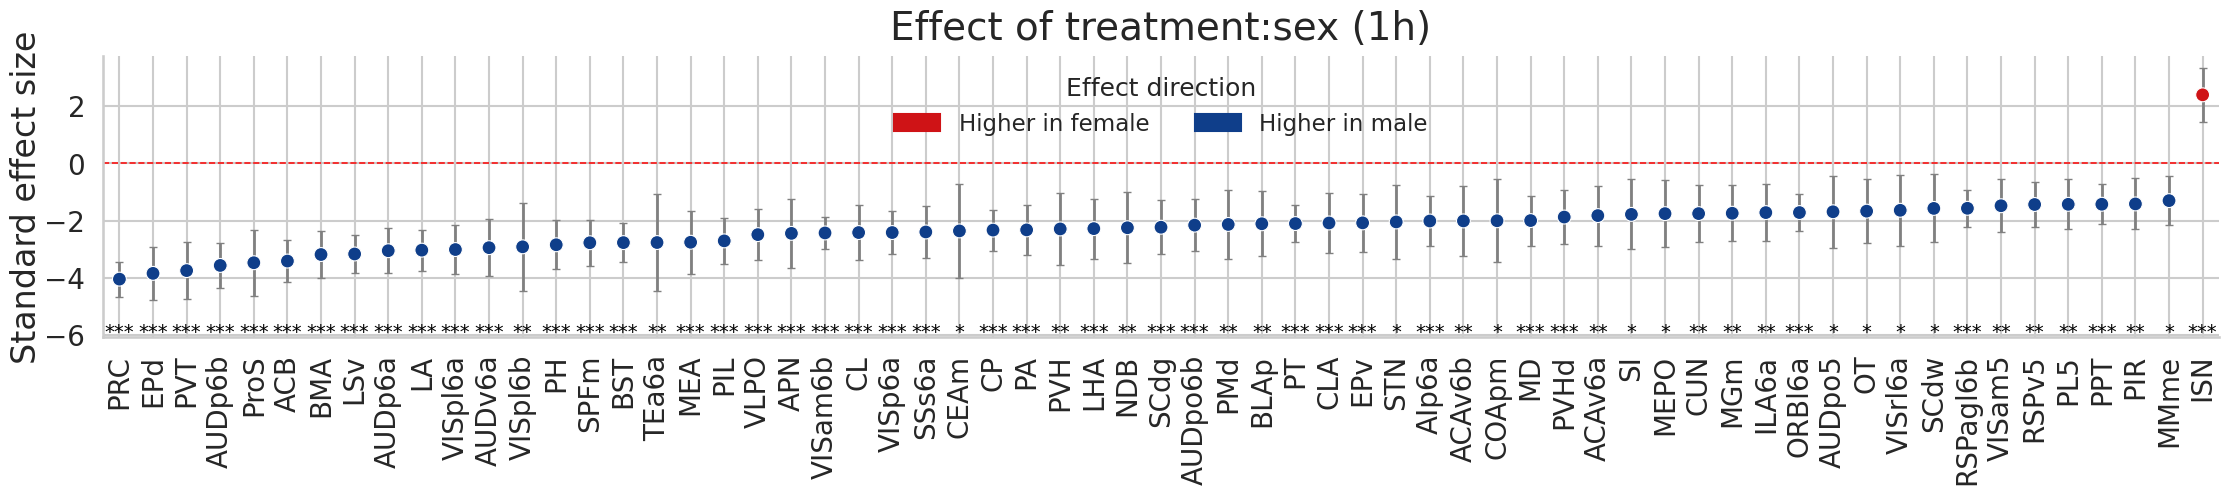

In [124]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# --- Prep

df["sign"] = np.where(df["effect"] >= 0, "positive", "negative")

order = list(df["structure"])
xpos = np.arange(len(df))

# --- Theme
sns.set_theme(style="whitegrid", context="talk")  # "talk" = larger fonts
plt.rcParams.update({
    "axes.labelsize": 24,
    "axes.titlesize": 28,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "font.weight": "regular"
})

# --- Figure
fig_w = 0.35 * len(df)
fig_h = 5
fig, ax = plt.subplots(figsize=(fig_w, fig_h))

# Scatter points
sns.scatterplot(
    x=xpos,
    y=df["effect"],
    hue=df["sign"],
    palette={"positive": "#cf1316", "negative": "#0f3e8a"},
    s=100,
    ax=ax,
    legend=False,
    zorder=3
)

# Vertical CI bars
for x, row in zip(xpos, df.itertuples()):
    ax.errorbar(
        x=x,
        y=row.effect,
        yerr=[[row.effect - row.lower_ci],
              [row.upper_ci - row.effect]],
        fmt="none",
        ecolor="gray",
        elinewidth=2,
        capsize=3,
        alpha=1,
        zorder=2
    )

# Reference line
ax.axhline(0, color="red", linestyle="--", lw=1.2, alpha=0.9)

# Labels
ax.set_xlabel("")
# ax.set_xlabel("Brain structure", labelpad=1)
ax.set_ylabel("Standard effect size", labelpad=1)
ax.set_title("Effect of treatment:sex (1h)", pad=12)

# Ticks
ax.set_xticks(xpos)
ax.set_xticklabels(order, rotation=90, ha="center")

legend_patches = [
    mpatches.Patch(color="#cf1316", label="Higher in female"),
    mpatches.Patch(color="#0f3e8a", label="Higher in male"),
]

ax.legend(
    handles=legend_patches,
    title="Effect direction",
    loc="upper center",
    bbox_to_anchor=(0.5, 1),
    ncol=2,
    frameon=False
)

# --- Layout tweaks
ax.set_xlim(-0.5, len(df) - 0.5)
sns.despine(left=False, bottom=False)
plt.tight_layout(pad=0.5)          # tighten figure padding
plt.subplots_adjust(left=0.02, right=0.98, bottom=0.32)  # reduce side margins

pval_col = "q"
def p_to_stars(p):
    if pd.isna(p): return ""
    if p < 1e-3:  return "***"
    if p < 1e-2:  return "**"
    if p < 0.05:  return "*"
    return ""

stars = df[pval_col].map(p_to_stars)

# Choose where that stars row lives (in data units)
ymin, ymax = ax.get_ylim()
rng = ymax - ymin
y_star = ymin - 0.08 * rng   # 8% below the current min (pick any value you like)

# Make sure the stars aren’t clipped
if y_star < ymin:
    ax.set_ylim(y_star - 0.02 * rng, ymax)  # tiny padding below

# Draw the star labels under each structure
for x, s in zip(xpos, stars):
    if s:
        ax.text(x, y_star, s, ha="center", va="center",
                fontsize=14, color="black", clip_on=False)

plt.savefig(
    os.path.join(SCREENSHOTS_FOLDER, "effect_treatment_sex_1h_d_marg.png"),
    dpi=300, bbox_inches="tight", transparent=True
)
plt.show()

In [125]:
df = pd.concat([positive_effects.copy(), negative_effects.copy()])
df = df.sort_values("effect").reset_index(drop=True)
structures_sex_diff_1h = df["structure"].to_list()
len(structures_sex_diff_1h)

80

In [126]:
print(structures_sex_diff_1h)

['PRC', 'EPd', 'PVT', 'AUDp6b', 'ProS', 'ACB', 'BMA', 'LSv', 'AUDp6a', 'LA', 'VISpl6a', 'AUDv6a', 'VISpl6b', 'PH', 'SPFm', 'BST', 'TEa6a', 'MEA', 'PIL', 'VLPO', 'APN', 'VISam6b', 'CL', 'VISp6a', 'SSs6a', 'DG-mo', 'CEAm', 'CP', 'PA', 'PVH', 'LHA', 'NDB', 'SCdg', 'AUDpo6b', 'PMd', 'BLAp', 'PT', 'CLA', 'EPv', 'STN', 'AIp6a', 'ACAv6b', 'COApm', 'MD', 'SUM', 'PVHd', 'ACAv6a', 'SI', 'RSPagl6a', 'MEPO', 'CUN', 'MGm', 'ILA6a', 'ORBl6a', 'AUDpo5', 'COApl', 'OT', 'VISrl6a', 'CA1', 'ORBm6a', 'ILA1', 'SCdw', 'RSPagl6b', 'VISam5', 'IMD', 'AUDd5', 'RSPv5', 'PL5', 'PPT', 'PIR', 'MMme', 'ENTm5', 'VISrl5', 'RSPd6a', 'MPN', 'AVP', 'SSs6b', 'AUDv4', 'IPI', 'ISN']


## Interaction effect treatment:sex at 4h (sex difference)

In [127]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")

    betas = []
    beta_lower_cis = []
    beta_upper_cis = []
    effects = []
    lower_cis = []
    upper_cis = []
    pvals = []
    
    for abbr in contributing_regions_no_parents:
        sub = lmm_df_full[lmm_df_full["region"] == abbr].copy()
        
        sub["treatment"] = pd.Categorical(sub["treatment"], categories=["saline", "morphine"], ordered=True)
        sub["time"]      = pd.Categorical(sub["time"], categories=["1h", "4h"], ordered=True)
        sub["sex"]       = pd.Categorical(sub["sex"], categories=["M", "F"], ordered=True)
        
        
        # 3) Fit the mixed model: density ~ treatment * time * sex + (1 | mouse_id)
        md = smf.mixedlm("density ~ C(treatment) * C(time) * C(sex)", 
                         data=sub, 
                         groups=sub["mouse_id"])
        m = md.fit(reml=True, method="lbfgs")
    
        b_tr_sexF   = "C(treatment)[T.morphine]:C(sex)[T.F]"
        b_tr_t4_sexF = "C(treatment)[T.morphine]:C(time)[T.4h]:C(sex)[T.F]"
        
        # Point estimate
        est = float(m.params[b_tr_sexF] + m.params[b_tr_t4_sexF])
        
        # SE via variance-of-a-sum
        cov = m.cov_params()
        v1 = cov.loc[b_tr_sexF, b_tr_sexF]
        v2 = cov.loc[b_tr_t4_sexF, b_tr_t4_sexF]
        c12 = cov.loc[b_tr_sexF, b_tr_t4_sexF]
        se = float(np.sqrt(v1 + v2 + 2*c12))
    
        ci = (est - 1.96*se, est + 1.96*se)
    
        # Standardize to marginal Cohen's d
        sigma_eps = float(np.sqrt(m.scale))  # residual SD
        var_u0 = float(m.cov_re.iloc[0, 0])  # random-intercept variance
        sd_marg = float(np.sqrt(m.scale + var_u0))  # marginal SD (Random intercept model)
        
        d_marg = est / sd_marg
        se_d_marg = se / sd_marg
        
        ci_d = (d_marg - 1.96*se_d_marg, d_marg + 1.96*se_d_marg)
    
        fe_names = m.fe_params.index
        w = pd.Series(0.0, index=fe_names) 
        w["C(treatment)[T.morphine]:C(sex)[T.F]"] = 1.0
        w["C(treatment)[T.morphine]:C(time)[T.4h]:C(sex)[T.F]"] = 1.0
        tt = m.t_test(w.values[None, :])
        pval = float(tt.pvalue)
    
        effects.append(d_marg)
        lower_cis.append(ci_d[0])
        upper_cis.append(ci_d[1])
        betas.append(est)
        beta_lower_cis.append(ci[0])
        beta_upper_cis.append(ci[1])
        pvals.append(pval)
    
    results_df = pd.DataFrame()
    results_df['structure'] = contributing_regions_no_parents
    results_df['beta'] = betas
    results_df['beta_lower_ci'] = beta_lower_cis
    results_df['beta_upper_ci'] = beta_upper_cis
    results_df['effect'] = effects
    results_df['lower_ci'] = lower_cis
    results_df['upper_ci'] = upper_cis
    results_df['abs_effect'] = np.abs(results_df['effect'].to_list())
    results_df['p'] = pvals
    reject, pvals_corrected, alphacSidak, alphacBonf = multipletests(
        pvals, alpha=0.05, method="fdr_bh"  # Benjamini-Hochberg FDR
    )
    results_df['q'] = pvals_corrected
    results_df.sort_values('abs_effect', ascending=False, inplace=True)

In [128]:
results_df

,structure,beta,beta_lower_ci,beta_upper_ci,effect,lower_ci,upper_ci,abs_effect,p,q
202,LRNm,-1.168290e+02,-212.144928,-21.512992,-2.582650e+00,-4.689728,-0.475572,2.582650e+00,0.016289,0.998493
198,VPMpc,2.078901e+02,12.593003,403.187131,2.250385e+00,0.136318,4.364453,2.250385e+00,0.036944,0.998493
173,PRP,-1.478595e+02,-276.860693,-18.858280,-2.177001e+00,-4.076343,-0.277659,2.177001e+00,0.024670,0.998493
114,VISp6b,4.433379e+02,2.752047,883.923699,2.130068e+00,0.013223,4.246913,2.130068e+00,0.048582,0.998493
36,PCG,-6.319778e+02,-1196.380439,-67.575096,-2.108579e+00,-3.991696,-0.225463,2.108579e+00,0.028187,0.998493
...,...,...,...,...,...,...,...,...,...,...
148,PRE,-2.909017e+00,-517.289496,511.471462,-1.187029e-02,-2.110808,2.087067,1.187029e-02,0.991156,0.998493
224,ENTm1,8.025038e+00,-1677.186876,1693.236952,9.877586e-03,-2.064359,2.084114,9.877586e-03,0.992553,0.998493
172,CEAm,-7.798511e-01,-171.589442,170.029740,-9.658588e-03,-2.125164,2.105847,9.658588e-03,0.992860,0.998493
102,RSPd1,7.900885e+00,-2403.221109,2419.022879,6.427930e-03,-1.955191,1.968047,6.427930e-03,0.994876,0.998493


In [129]:
results_df[results_df['q'] < 0.05]

,structure,beta,beta_lower_ci,beta_upper_ci,effect,lower_ci,upper_ci,abs_effect,p,q


In [130]:
d_thresh = 0.8
results_df_large = results_df[results_df['abs_effect'] >= d_thresh]
positive_effects = results_df_large[results_df_large['effect'] > 0]
positive_effects = positive_effects[positive_effects["lower_ci"] > 0]
positive_effects.shape

(4, 10)

In [131]:
negative_effects = results_df[results_df['effect'] < 0]
negative_effects = negative_effects[negative_effects["upper_ci"] < 0]
negative_effects.shape

(6, 10)

In [132]:
df = pd.concat([positive_effects.copy(), negative_effects.copy()])
df = df.sort_values("effect").reset_index(drop=True)

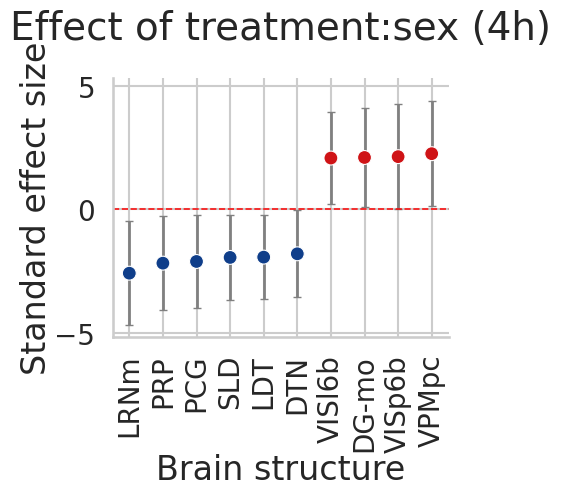

In [133]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# --- Prep
df = pd.concat([positive_effects.copy(), negative_effects.copy()])
df = df.sort_values("effect").reset_index(drop=True)
df["sign"] = np.where(df["effect"] >= 0, "positive", "negative")

order = list(df["structure"])
xpos = np.arange(len(df))

# --- Theme
sns.set_theme(style="whitegrid", context="talk")  # "talk" = larger fonts
plt.rcParams.update({
    "axes.labelsize": 24,
    "axes.titlesize": 28,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "font.weight": "regular"
})

# --- Figure
fig_w = 0.35 * len(df)
fig_h = 5
fig, ax = plt.subplots(figsize=(fig_w, fig_h))

# Scatter points
sns.scatterplot(
    x=xpos,
    y=df["effect"],
    hue=df["sign"],
    palette={"positive": "#cf1316", "negative": "#0f3e8a"},
    s=100,
    ax=ax,
    legend=False,
    zorder=3
)

# Vertical CI bars
for x, row in zip(xpos, df.itertuples()):
    ax.errorbar(
        x=x,
        y=row.effect,
        yerr=[[row.effect - row.lower_ci],
              [row.upper_ci - row.effect]],
        fmt="none",
        ecolor="gray",
        elinewidth=2,
        capsize=3,
        alpha=1,
        zorder=2
    )

# Reference line
ax.axhline(0, color="red", linestyle="--", lw=1.2, alpha=0.9)

# Labels
ax.set_xlabel("Brain structure", labelpad=1)
ax.set_ylabel("Standard effect size", labelpad=1)
ax.set_title("Effect of treatment:sex (4h)", pad=28)

# Ticks
ax.set_xticks(xpos)
ax.set_xticklabels(order, rotation=90, ha="center")

# --- Layout tweaks
ax.set_xlim(-0.5, len(df) - 0.5)
sns.despine(left=False, bottom=False)
plt.tight_layout(pad=0.5)          # tighten figure padding
plt.subplots_adjust(left=0.02, right=0.98, bottom=0.32)  # reduce side margins

ymin, ymax = ax.get_ylim()
rng = ymax - ymin
ax.set_ylim(ymin, ymax+0.05*rng)

plt.savefig(
    os.path.join(SCREENSHOTS_FOLDER, "effect_treatment_sex_4h_d_marg.png"),
    dpi=300, bbox_inches="tight", transparent=True
)
plt.show()

In [134]:
structures_sex_diff_4h = df["structure"].to_list()
len(structures_sex_diff_4h)

10

In [135]:
print(structures_sex_diff_4h)

['LRNm', 'PRP', 'PCG', 'SLD', 'LDT', 'DTN', 'VISl6b', 'DG-mo', 'VISp6b', 'VPMpc']


In [136]:
SCREENSHOTS_FOLDER = "brainrender/response_to_review"
import brainrender
brainrender.settings.vsettings.screenshot_transparent_background = True
from brainrender import Scene
from brainrender._colors import map_color
alpha = 0.5

class CustomScene(Scene):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

    def _make_axes(self):
        return {}

brainrender.settings.SHADER_STYLE = "glossy"
alpha = 0.4

scene1 = CustomScene(screenshots_folder=SCREENSHOTS_FOLDER, atlas_name="allen_mouse_10um")
for region in set(structures_sex_diff_1h)-set(structures_sex_diff_4h):
    scene1.add_brain_region(
    region,
    alpha=alpha,
    color="#7570B3" # "purple"
)
for region in structures_sex_diff_4h:
    scene1.add_brain_region(
    region,
    alpha=alpha,
    color="#1B9E77"  # "green"
)

scene1.slice('sagittal')
scene1.render(interactive=False, zoom=1)
scene1.screenshot(name="structures_w_sex_differences")

Saving new screenshot at structures_w_sex_differences.png

'brainrender/response_to_review/structures_w_sex_differences.png'

In [137]:
structures_sex_diff = structures_sex_diff_1h + structures_sex_diff_4h


large_structures = ['Isocortex', 'CTXsp', 'HPF', 'OLF', 'HY', 'MB', 'P', 'PAL', 'STR', 'TH', 'MY', 'CB']
major_regions = [get_major_parent(x) for x in structures_sex_diff]

sex_diff_df = pd.DataFrame()
sex_diff_df["region"] = list(structures_sex_diff)
sex_diff_df["parent"] = major_regions

grouped = sex_diff_df.groupby('parent')
for parent, group in grouped:
    print(f"\nGroup: {parent}")
    print(len(group["region"].to_list()))
    print(sorted(group["region"].to_list()))


Group: CTXsp
7
['BLAp', 'BMA', 'CLA', 'EPd', 'EPv', 'LA', 'PA']

Group: HPF
5
['CA1', 'DG-mo', 'DG-mo', 'ENTm5', 'ProS']

Group: HY
12
['AVP', 'LHA', 'MEPO', 'MMme', 'MPN', 'PH', 'PMd', 'PVH', 'PVHd', 'STN', 'SUM', 'VLPO']

Group: Isocortex
31
['ACAv6a', 'ACAv6b', 'AIp6a', 'AUDd5', 'AUDp6a', 'AUDp6b', 'AUDpo5', 'AUDpo6b', 'AUDv4', 'AUDv6a', 'ILA1', 'ILA6a', 'ORBl6a', 'ORBm6a', 'PL5', 'RSPagl6a', 'RSPagl6b', 'RSPd6a', 'RSPv5', 'SSs6a', 'SSs6b', 'TEa6a', 'VISam5', 'VISam6b', 'VISl6b', 'VISp6a', 'VISp6b', 'VISpl6a', 'VISpl6b', 'VISrl5', 'VISrl6a']

Group: MB
7
['APN', 'CUN', 'IPI', 'PPT', 'PRC', 'SCdg', 'SCdw']

Group: MY
3
['ISN', 'LRNm', 'PRP']

Group: OLF
3
['COApl', 'COApm', 'PIR']

Group: P
4
['DTN', 'LDT', 'PCG', 'SLD']

Group: PAL
3
['BST', 'NDB', 'SI']

Group: STR
6
['ACB', 'CEAm', 'CP', 'LSv', 'MEA', 'OT']

Group: TH
9
['CL', 'IMD', 'MD', 'MGm', 'PIL', 'PT', 'PVT', 'SPFm', 'VPMpc']
